In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import fsolve
from scipy.optimize import root_scalar
from scipy import signal
import math
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
from sklearn.metrics import r2_score

# characteristics of the dataset

In [3]:
data = pd.read_csv('/Users/34633/Documents/master/tfm/data/chinadata/user.csv', sep =',', encoding = 'latin1')
print(data.shape)
data.head()

(467, 3)


,user_id,gender,grade
0,219,1,4
1,220,1,4
2,280,0,3
3,430,1,5
4,291,1,3


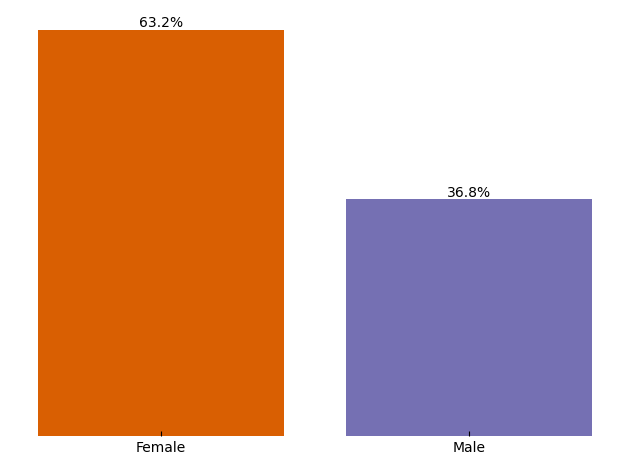

In [4]:
gender_map = {0: 'Male', 1: 'Female'}
data['gender_label'] = data['gender'].map(gender_map)
cmap = plt.get_cmap('Dark2')
selected_indices = [1,2]
colors = [cmap(i) for i in selected_indices]
count = data['gender_label'].value_counts().sort_values(ascending=False)
total = count.sum()

fig, ax = plt.subplots()
bars = ax.bar(count.index, count.values, color=colors)
ax.set_ylabel('Count')
ax.yaxis.set_visible(False)
for spine in ax.spines.values():
    spine.set_visible(False)
for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{percentage:.1f}%', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.tick_params(axis='both', direction='in')
#plt.savefig('figs/gender.png')

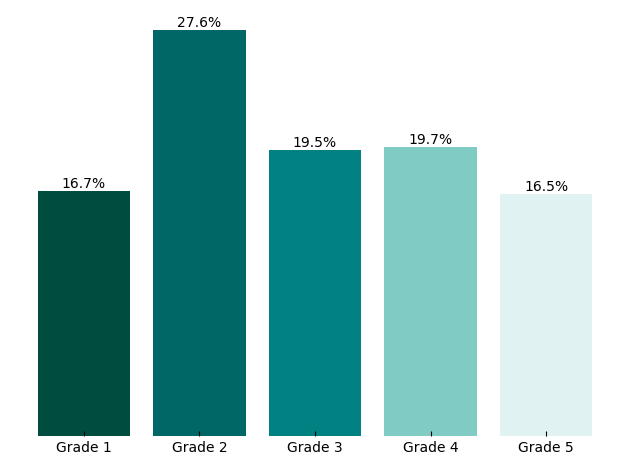

In [5]:
import matplotlib.colors as mcolors
grade_map = {1: 'Grade 1', 2: 'Grade 2', 3: 'Grade 3', 4: 'Grade 4', 5: 'Grade 5'}
data['grade_label'] = data['grade'].map(grade_map)

teal_colors = ["#004d40", "#006666", "#008080", "#80cbc4", "#e0f2f2"]
teal_cmap = mcolors.LinearSegmentedColormap.from_list("teal_dark_light", teal_colors)

count = data['grade_label'].value_counts().sort_index()
total = count.sum()
colors = [teal_cmap(i) for i in np.linspace(0, 1, len(count))]

fig, ax = plt.subplots()
bars = ax.bar(count.index, count.values, color=colors)

ax.set_ylabel('Count')
ax.yaxis.set_visible(False)

for spine in ax.spines.values():
    spine.set_visible(False)

for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{percentage:.1f}%', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.tick_params(axis='both', direction='in')
#plt.savefig('figs/grade.png')
plt.show()

In [6]:
checkins = pd.read_csv('/Users/34633/Documents/master/tfm/data/chinadata/checkIns.csv', sep =',', encoding = 'latin1')
print(checkins.shape)
checkins.head()
checkins.columns.tolist()

(20397, 9)


['user_id',
 'day',
 'day_of_week',
 'time',
 'latitude',
 'longitude',
 'POI_id',
 'POI_category',
 'mood']

In [7]:
checkins.columns.tolist()
checkinsbyid = checkins['user_id'].value_counts()
print(checkinsbyid)

user_id
99     92
408    92
307    85
120    83
324    78
       ..
211    26
443    25
389    25
407    25
62     25
Name: count, Length: 467, dtype: int64


In [8]:
checkins = checkins.merge(data[['user_id', 'gender']], on='user_id', how='left')
checkins.columns.tolist()
checkins['time'] = pd.to_datetime(checkins['time'])
checkins['mov_day'] = (checkins['time'] - pd.Timedelta(hours=4)).dt.date

C:\Users\34633\AppData\Local\Temp\ipykernel_15640\3778694713.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  checkins['time'] = pd.to_datetime(checkins['time'])


# DEFINITON OF ENTROPY FUNCTIONS

In [9]:
def shannon_entropy(probs):
    return -np.sum(probs * np.log2(probs))

#UNCORRELATED ENTROPY
def compute_hu(seq):
    if len(seq) == 0: return 0
    probs = pd.Series(seq).value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))

#CORRELATED ENTROPY
def find_shortest_new_sequence(sequence, i):
    n = len(sequence)
    for length in range(1, n - i + 1):
        sub_sequence = sequence[i:i + length]
        is_seen = False
        for j in range(i):
            if sequence[j:j + length] == sub_sequence:
                is_seen = True
                break
        if not is_seen:
            return length
    return n - i + 1

def compute_hc(sequence):
    n = len(sequence)
    if n < 2:
        return np.nan
    
    total_lambda = 0
    for i in range(n):
        total_lambda += find_shortest_new_sequence(sequence, i)
        
    return (n * np.log2(n)) / total_lambda

def binary_entropy(x):
    if x <= 0 or x >= 1:
        return 0
    return -x * np.log2(x) - (1 - x) * np.log2(1 - x)

def fano_inequality_root(pi, h, s):
    return h - (binary_entropy(pi) + (1 - pi) * np.log2(s - 1))

def calculate_predictability(h, s):
    if s <= 1 or h <= 0:
        return 1.0
    h_max = np.log2(s)
    if h >= h_max:
        return 1.0 / s
    lower_bound = 1.0 / s
    upper_bound = 0.999999
    try:
        sol = root_scalar(fano_inequality_root, args=(h, s), 
                         bracket=[lower_bound, upper_bound], method='brentq')
        return sol.root
    except (ValueError, RuntimeError):
        return lower_bound

# UNCORRELATED ENTROPY (shannon)

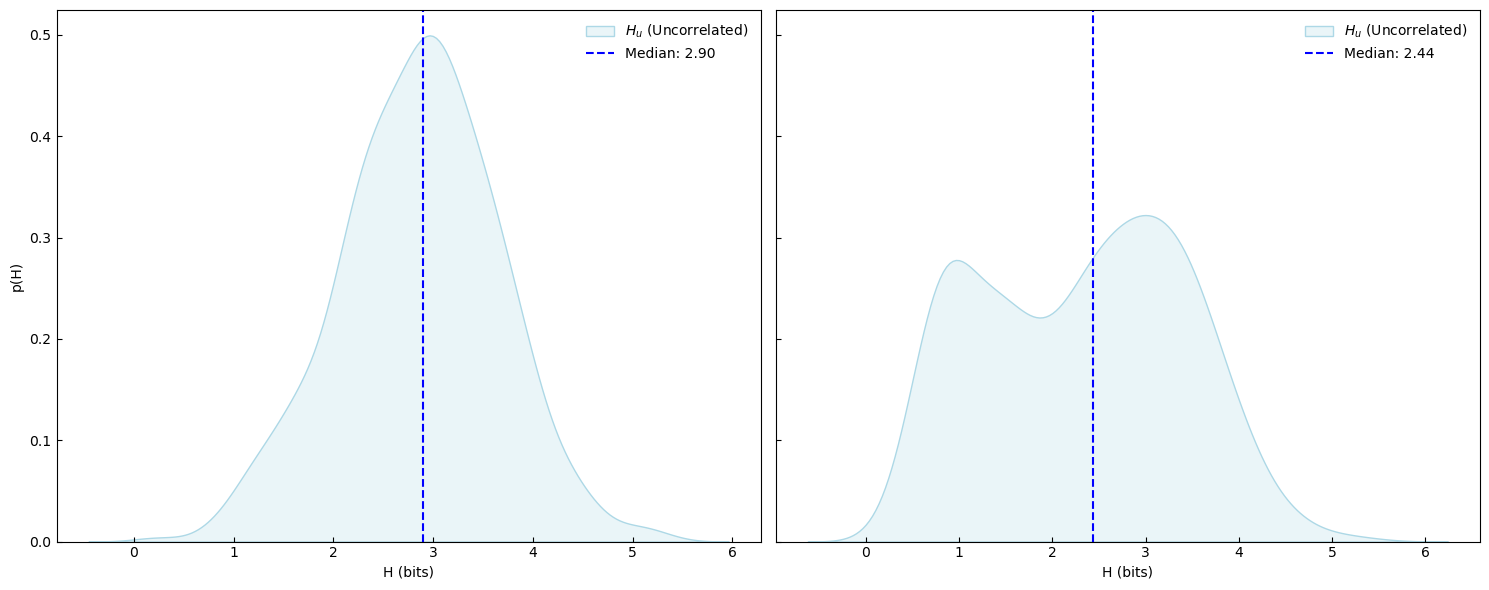

Cantidad de elementos en Plot Izquierdo (Por Usuario): 467
Cantidad de elementos en Plot Derecho (Por Usuario-Día): 729
Usuarios únicos reales en el Plot Derecho: 467


In [14]:
#ENTROPY CALCULATED WITHOUT DAY ADJUSTMENT
checkins = checkins.sort_values(by=['user_id', 'day', 'time'])
user_sequences = checkins.groupby('user_id')['POI_id'].apply(list)
user_sequences = user_sequences[user_sequences.apply(len) > 1]
hu_values_BAD = user_sequences.apply(compute_hu)

#ADJUSTED DAY TO INCLUDE EARLY MORNING HOURS
checkins = checkins.sort_values(by=['user_id', 'day', 'time'])
user_sequences = checkins.groupby(['user_id', 'mov_day'])['POI_id'].apply(list)
user_sequences = user_sequences[user_sequences.apply(lambda x: len(set(x)) > 1)]
hu_values = user_sequences.apply(compute_hu)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

sns.kdeplot(hu_values_BAD, fill=True, color='lightblue', label='$H_u$ (Uncorrelated)', ax=ax1)
ax1.axvline(hu_values_BAD.median(), linestyle='--', color='blue', label=f'Median: {hu_values_BAD.median():.2f}')
ax1.set_xlabel('H (bits)')
ax1.set_ylabel('p(H)')
ax1.legend(frameon=False)
ax1.tick_params(axis='both', direction='in')

sns.kdeplot(hu_values, fill=True, color='lightblue', label='$H_u$ (Uncorrelated)', ax=ax2)
ax2.axvline(hu_values.median(), linestyle='--', color='blue', label=f'Median: {hu_values.median():.2f}')
ax2.set_xlabel('H (bits)')
ax2.set_ylabel('p(H)')
ax2.legend(frameon=False)
ax2.tick_params(axis='both', direction='in')

plt.tight_layout()
plt.show()

print(f"Cantidad de elementos en Plot Izquierdo (Por Usuario): {len(hu_values_BAD)}")
print(f"Cantidad de elementos en Plot Derecho (Por Usuario-Día): {len(hu_values)}")

# Para saber cuántos usuarios únicos sobrevivieron en el segundo filtro:
print(f"Usuarios únicos reales en el Plot Derecho: {len(hu_values.index.get_level_values('user_id').unique())}")

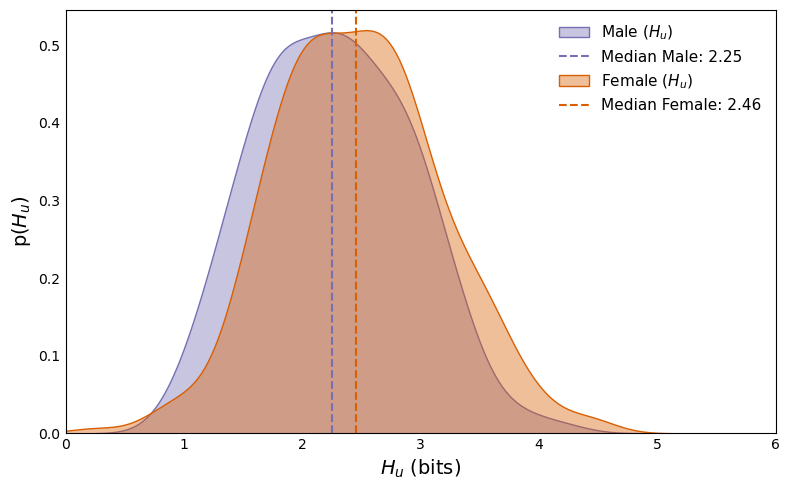

-0.20762942086709968


In [11]:
daily_entropy = checkins.groupby(['user_id', 'mov_day', 'gender'])['POI_id'].apply(list).reset_index()
daily_entropy = daily_entropy[daily_entropy['POI_id'].apply(lambda x: len(set(x)) > 1)]
daily_entropy['Hu_val'] = daily_entropy['POI_id'].apply(compute_hu)
user_entropy_final = daily_entropy.groupby(['user_id', 'gender'])['Hu_val'].mean().reset_index()
hu_male = user_entropy_final[user_entropy_final['gender'] == 0]['Hu_val']
hu_female = user_entropy_final[user_entropy_final['gender'] == 1]['Hu_val']

cmap = plt.get_cmap('Dark2')
selected_indices = [1,2]
colors = [cmap(i) for i in selected_indices]

plt.figure(figsize=(8,5))
sns.kdeplot(hu_male, fill=True, color=colors[1], label='Male ($H_u$)', alpha=0.4)
plt.axvline(hu_male.median(), color=colors[1], linestyle='--',  label=f'Median Male: {hu_male.median():.2f}')
sns.kdeplot(hu_female, fill=True, color=colors[0], label='Female ($H_u$)', alpha=0.4)
plt.axvline(hu_female.median(), color=colors[0], linestyle='--', label=f'Median Female: {hu_female.median():.2f}')
plt.xlabel('$H_u$ (bits)', fontsize=14)
plt.ylabel('p($H_u$)', fontsize=14)
plt.legend(frameon=False, fontsize=11)
plt.tick_params(axis='both', direction='in', length=0)
plt.xlim(0, 6)
plt.tight_layout()
#plt.savefig('figs/unc.png')
plt.show()

print(hu_male.median()-hu_female.median())

# CORRELATED ENTROPY

as it says in the paper, the most info we use, the less entropy our system will have because it will be more defined. we hope to get lower values of correlated entropy that for uncorrelated

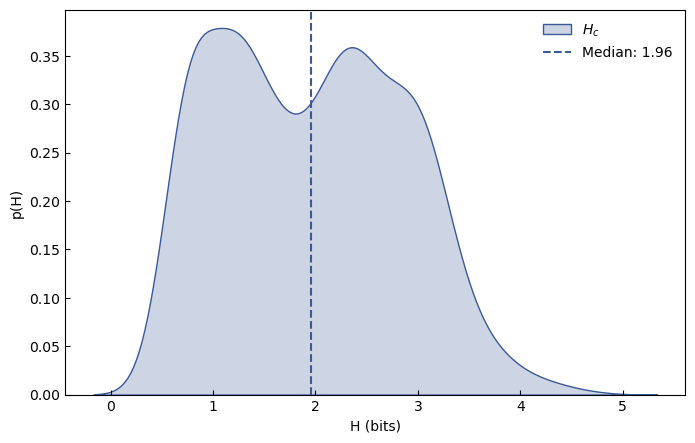

In [12]:
checkins = checkins.sort_values(by=['user_id', 'day', 'time'])
results_hc = checkins.groupby(['user_id', 'mov_day'])['POI_id'].apply(list).apply(compute_hc).dropna()

plt.figure(figsize=(8, 5))
sns.kdeplot(results_hc, fill=True, color='#3b5998', label='$H_c$')
plt.axvline(results_hc.median(), color='#3b5998', linestyle='--', label=f'Median: {results_hc.median():.2f}')
plt.xlabel('H (bits)')
plt.ylabel('p(H)')
plt.legend(frameon=False)
plt.tick_params(axis='both', direction='in')
plt.show()

467


FileNotFoundError: [Errno 2] No such file or directory: 'figs/corr.png'

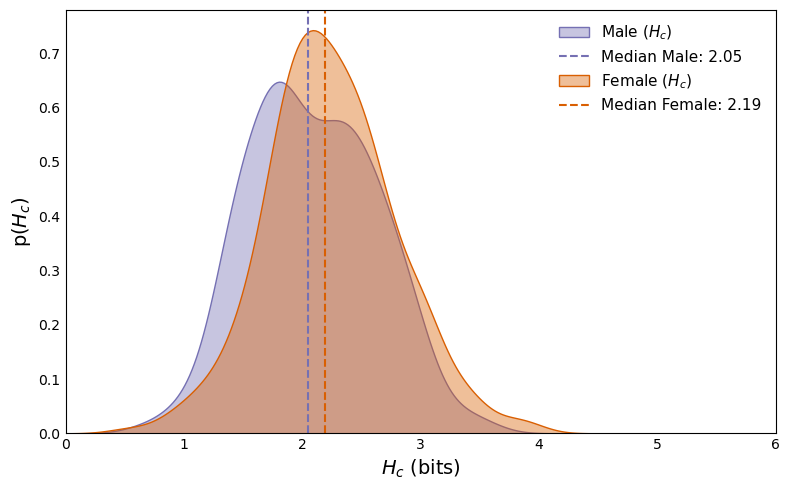

In [ ]:
daily_hc = checkins.groupby(['user_id', 'mov_day', 'gender'])['POI_id'].apply(list).reset_index()
daily_hc = daily_hc[daily_hc['POI_id'].apply(lambda x: len(set(x)) > 1)]
daily_hc['Hc_val'] = daily_hc['POI_id'].apply(compute_hc)
user_hc_final = daily_hc.groupby(['user_id', 'gender'])['Hc_val'].mean().reset_index()

hc_male = user_hc_final[user_hc_final['gender'] == 0]['Hc_val']
hc_female = user_hc_final[user_hc_final['gender'] == 1]['Hc_val']

cmap = plt.get_cmap('Dark2')
selected_indices = [1,2]
colors = [cmap(i) for i in selected_indices]

plt.figure(figsize=(8, 5))
sns.kdeplot(hc_male, fill=True, color=colors[1], label='Male ($H_c$)', alpha=0.4)
plt.axvline(hc_male.median(), color=colors[1], linestyle='--', label=f'Median Male: {hc_male.median():.2f}')
sns.kdeplot(hc_female, fill=True, color=colors[0], label='Female ($H_c$)', alpha=0.4)
plt.axvline(hc_female.median(), color=colors[0], linestyle='--', label=f'Median Female: {hc_female.median():.2f}')
plt.xlabel('$H_c$ (bits)', fontsize=14)
plt.ylabel('p($H_c$)', fontsize = 14)
plt.legend(frameon=False, fontsize=11)
plt.tick_params(axis='both', direction='in', length=0)
plt.xlim(0, 6) 
plt.tight_layout()
#plt.savefig('figs/corr.png')
plt.show()

print(hc_female.median()-hc_male.median())

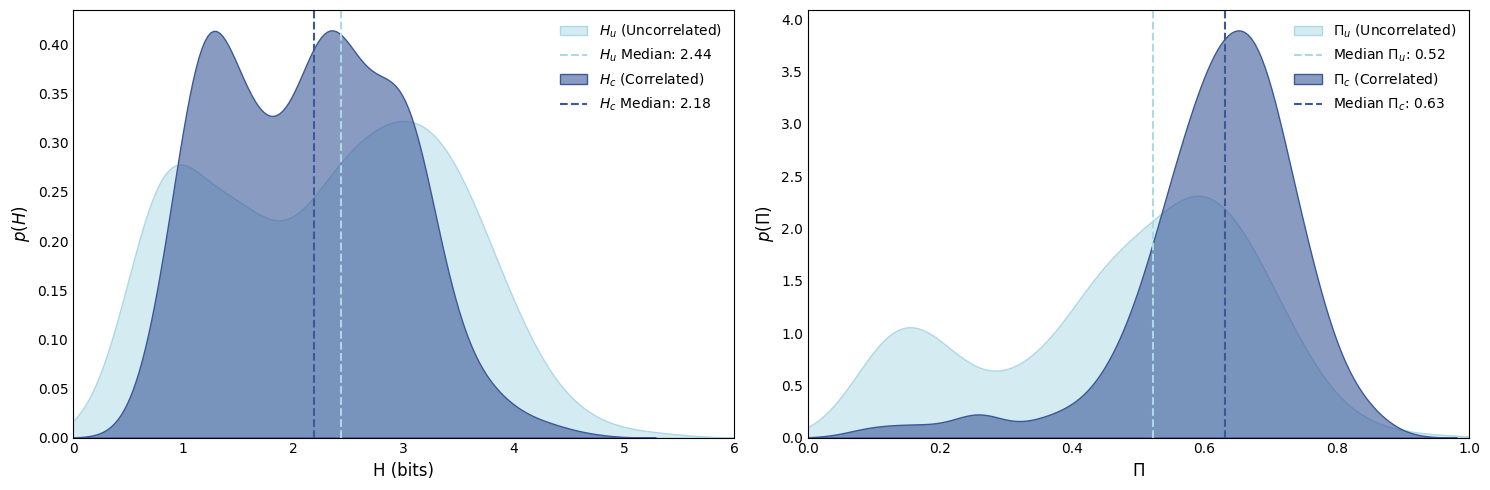

In [36]:
entropy_comparison = pd.DataFrame({'Hu': hu_values,'Hc': results_hc}).dropna()

daily_S = checkins.groupby(['user_id', 'mov_day'])['POI_id'].nunique().reset_index()
avg_S_per_user = daily_S.groupby('user_id')['POI_id'].mean()

def to_clean_series(data):
    if isinstance(data, pd.DataFrame):
        return data.iloc[:, 0]
    return data

hu_series = to_clean_series(hu_values)
hc_series = to_clean_series(results_hc)
if isinstance(hu_series.index, pd.MultiIndex):
    hu_series = hu_series.groupby(level='user_id').mean()
if isinstance(hc_series.index, pd.MultiIndex):
    hc_series = hc_series.groupby(level='user_id').mean()

predict_input = pd.DataFrame({'Hu': hu_series,'Hc': hc_series,'S_avg': avg_S_per_user}).dropna()
predictability_results = []
for uid, row in predict_input.iterrows():
    s = row['S_avg']
    if s > 1:
        pi_u = calculate_predictability(row['Hu'], s)
        pi_c = calculate_predictability(row['Hc'], s)
        predictability_results.append({'user_id': uid, 'Pi_u': pi_u,  'Pi_c': pi_c})

predictability_df = pd.DataFrame(predictability_results)

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
sns.kdeplot(entropy_comparison['Hu'], fill=True, color='lightblue', label='$H_u$ (Uncorrelated)', alpha=0.5)
plt.axvline(entropy_comparison['Hu'].median(), color='lightblue', linestyle='--', linewidth=1.5, label=f"$H_u$ Median: {entropy_comparison['Hu'].median():.2f}")
sns.kdeplot(entropy_comparison['Hc'], fill=True, color='#3b5998', label='$H_c$ (Correlated)', alpha=0.6)
plt.axvline(entropy_comparison['Hc'].median(), color='#3b5998', linestyle='--', linewidth=1.5, label=f"$H_c$ Median: {entropy_comparison['Hc'].median():.2f}")
plt.xlabel('H (bits)', fontsize=12)
plt.ylabel('$p(H)$', fontsize=12)
plt.xlim(0, 6) 
plt.legend(frameon=False, fontsize=10)
plt.tick_params(axis='both', length=0)

plt.subplot(1, 2, 2)
sns.kdeplot(predictability_df['Pi_u'], fill=True, color='lightblue', label='$\Pi_u$ (Uncorrelated)', alpha=0.5)
plt.axvline(predictability_df['Pi_u'].median(), color='lightblue', linestyle='--', linewidth=1.5, label=f"Median $\Pi_u$: {predictability_df['Pi_u'].median():.2f}")
sns.kdeplot(predictability_df['Pi_c'], fill=True, color='#3b5998', label='$\Pi_c$ (Correlated)', alpha=0.6)
plt.axvline(predictability_df['Pi_c'].median(), color='#3b5998', linestyle='--', linewidth=1.5, label=f"Median $\Pi_c$: {predictability_df['Pi_c'].median():.2f}")
plt.xlabel('$\Pi$', fontsize=12)
plt.ylabel('$p(\Pi)$', fontsize=12)
plt.xlim(0, 1)
plt.legend(frameon=False, fontsize=10)
plt.tick_params(axis='both', length=0)

plt.tight_layout()
plt.savefig('figs/comp.png', bbox_inches='tight', dpi=300)

p-value (Wilcoxon Hu > Hc): 9.720837686086287e-36


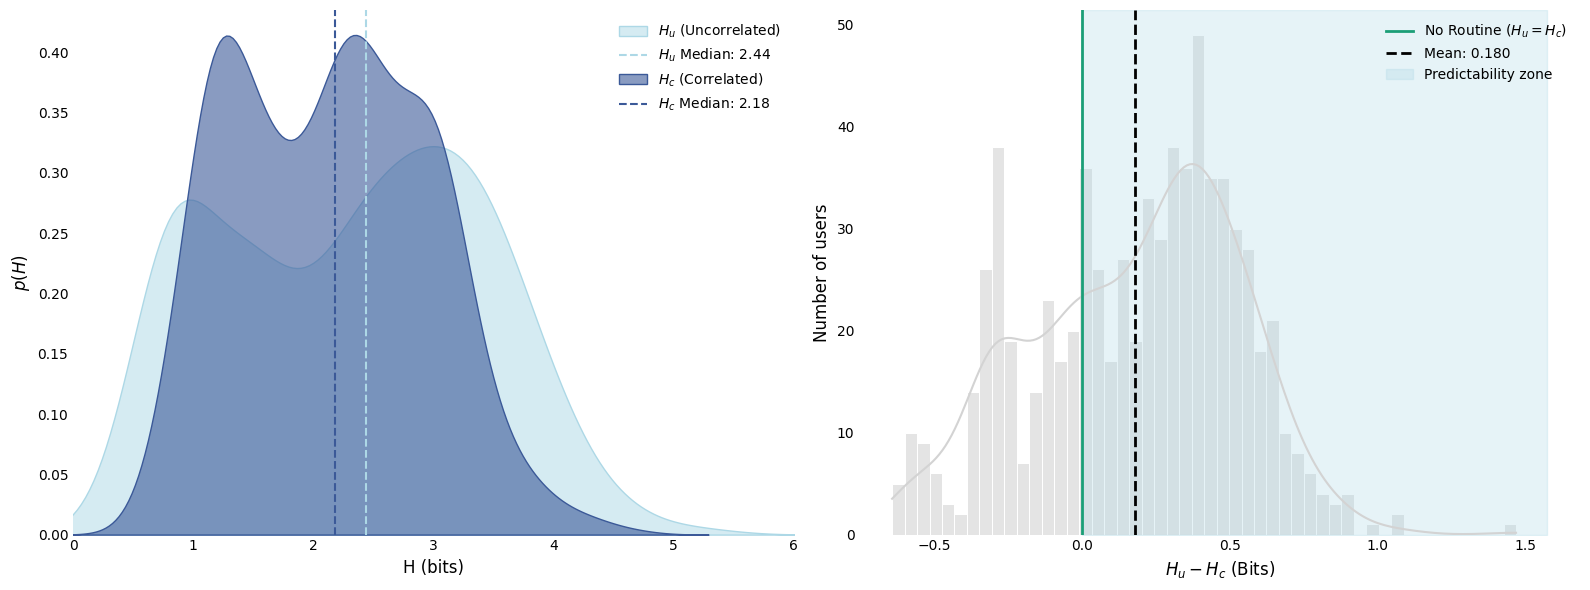

0.2521388561149407


In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import wilcoxon

# ==========================================
# 1. PROCESAMIENTO DE DATOS Y CÁLCULOS
# ==========================================

entropy_comparison = pd.DataFrame({'Hu': hu_values, 'Hc': results_hc}).dropna()

# Asegurar los datos para el análisis de diferencias (Wilcoxon)
user_stats = pd.DataFrame({
    'Hu': to_clean_series(hu_values),
    'Hc': to_clean_series(results_hc)
}).dropna()

user_stats['diff'] = user_stats['Hu'] - user_stats['Hc']

# Test estadístico de Wilcoxon
stat, p_val = wilcoxon(user_stats['Hu'], user_stats['Hc'], alternative='greater')
print(f"p-value (Wilcoxon Hu > Hc): {p_val}")


# ==========================================
# 2. CONSTRUCCIÓN DEL PANEL (1 fila, 2 columnas)
# ==========================================

fig, axs = plt.subplots(1, 2, figsize=(16, 6))
cmap = plt.get_cmap('Dark2')

# --- SUBPLOT 1: Comparativa de Densidades (Izquierda) ---
sns.kdeplot(entropy_comparison['Hu'], fill=True, color='lightblue', label='$H_u$ (Uncorrelated)', alpha=0.5, ax=axs[0])
axs[0].axvline(entropy_comparison['Hu'].median(), color='lightblue', linestyle='--', linewidth=1.5, 
               label=f"$H_u$ Median: {entropy_comparison['Hu'].median():.2f}")

sns.kdeplot(entropy_comparison['Hc'], fill=True, color='#3b5998', label='$H_c$ (Correlated)', alpha=0.6, ax=axs[0])
axs[0].axvline(entropy_comparison['Hc'].median(), color='#3b5998', linestyle='--', linewidth=1.5, 
               label=f"$H_c$ Median: {entropy_comparison['Hc'].median():.2f}")

axs[0].set_xlabel('H (bits)', fontsize=12)
axs[0].set_ylabel('$p(H)$', fontsize=12)
axs[0].set_xlim(0, 6) 
axs[0].legend(frameon=False, fontsize=10, loc='upper right')
axs[0].tick_params(axis='both', length=0)


# --- SUBPLOT 2: Histograma de Diferencias (Derecha) ---
sns.histplot(user_stats['diff'], bins=50, kde=True, color='lightgray', edgecolor='white', alpha=0.6, ax=axs[1])
axs[1].axvline(0, color=cmap(0), linestyle='-', lw=2, label='No Routine ($H_u = H_c$)')
axs[1].axvline(user_stats['diff'].mean(), color='black', linestyle='--', lw=2, 
               label=f'Mean: {user_stats["diff"].mean():.3f}')

# Obtener límites dinámicos de Y para rellenar la zona de predictibilidad correctamente
y_max_1 = axs[1].get_ylim()[1]
x_max_1 = axs[1].get_xlim()[1]
axs[1].fill_betweenx(y=[0, y_max_1], x1=0, x2=x_max_1, color='lightblue', alpha=0.3, label='Predictability zone')

# Anotación opcional del p-value (puedes descomentarla si deseas verla en la gráfica)
# axs[1].text(user_stats['diff'].mean()*1.1, y_max_1*0.8, f'p-value: {p_val:.2e}', bbox=dict(facecolor='white', alpha=0.5))

axs[1].set_xlabel('$H_u - H_c$ (Bits)', fontsize=12)
axs[1].set_ylabel('Number of users', fontsize=12)
axs[1].set_ylim(0, y_max_1) # Reajustar para mantener la consistencia tras el fill
axs[1].legend(frameon=False, fontsize=10, loc='upper right')
axs[1].tick_params(axis='both', length=0)


# ==========================================
# 3. AJUSTES FINALES Y GUARDADO
# ==========================================

# Eliminar todos los bordes (spines) de ambos gráficos de forma unificada
for ax in axs:
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig('figs/entropy_and_diff_panel.png', dpi=300, bbox_inches='tight')
plt.show()

print(entropy_comparison['Hu'].median()-entropy_comparison['Hc'].median())

Iniciando Shuffling de trayectorias con Intervalo de Confianza...


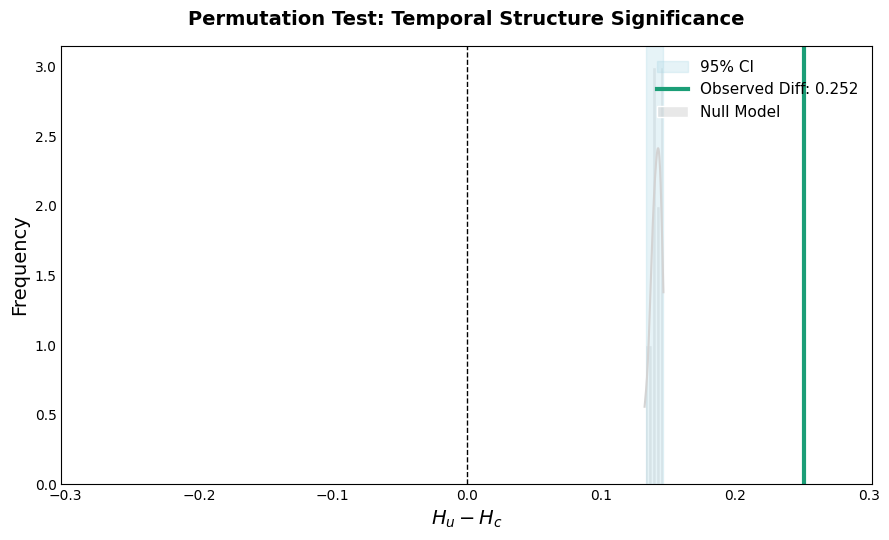


--- RESULTADOS DEL MODELO NULO ---
95% Confidence Interval: [0.13386, 0.14624]
Diferencia Observada Real: 0.2521
p-value: 0.000000


In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==========================================
# 1. SIMULACIÓN DEL MODELO NULO (SHUFFLING)
# ==========================================

obs_diff_global = 0.2521388561149407  # Tu diferencia real observada (~0.25)

null_diffs_trajectory = []
n_permutations = 10  # Ajusta según la potencia de tu máquina

print("Iniciando Shuffling de trayectorias con Intervalo de Confianza...")

for i in range(n_permutations):
    shuffled_checkins = checkins.copy()
    
    # Rompemos el orden temporal mezclando aleatoriamente los POIs por usuario y día
    shuffled_checkins['POI_id'] = shuffled_checkins.groupby(['user_id', 'mov_day'])['POI_id'].transform(np.random.permutation)
    
    # Recalculamos Hu nulo
    daily_entropy_null = shuffled_checkins.groupby(['user_id', 'mov_day'])['POI_id'].apply(list).reset_index()
    daily_entropy_null = daily_entropy_null[daily_entropy_null['POI_id'].apply(lambda x: len(set(x)) > 1)]
    daily_entropy_null['Hu_val'] = daily_entropy_null['POI_id'].apply(compute_hu)
    user_hu_null = daily_entropy_null.groupby('user_id')['Hu_val'].mean()
    
    # Recalculamos Hc nulo
    daily_hc_null = shuffled_checkins.groupby(['user_id', 'mov_day'])['POI_id'].apply(list).reset_index()
    daily_hc_null = daily_hc_null[daily_hc_null['POI_id'].apply(lambda x: len(set(x)) > 1)]
    daily_hc_null['Hc_val'] = daily_hc_null['POI_id'].apply(compute_hc)
    user_hc_null = daily_hc_null.groupby('user_id')['Hc_val'].mean()
    
    # Guardamos la diferencia promedio simulada
    null_diff = (user_hu_null - user_hc_null).mean()
    null_diffs_trajectory.append(null_diff)

null_diffs_trajectory = np.array(null_diffs_trajectory)

# Cálculos estadísticos finales del modelo nulo
ci_low_traj = np.percentile(null_diffs_trajectory, 2.5)
ci_high_traj = np.percentile(null_diffs_trajectory, 97.5)
p_val_trajectory = np.mean(null_diffs_trajectory >= obs_diff_global)


# ==========================================
# 2. GRÁFICO DEL MODELO NULO CON CI
# ==========================================

plt.figure(figsize=(9, 5.5))
cmap = plt.get_cmap('Dark2')
sns.histplot(null_diffs_trajectory, kde=True, color='lightgray', edgecolor='white', label='Null Model')
plt.axvspan(ci_low_traj, ci_high_traj, color='lightblue', alpha=0.3, label='95% CI')
plt.axvline(obs_diff_global, color=cmap(0), lw=3, linestyle='-', label=f'Observed Diff: {obs_diff_global:.3f}')
plt.axvline(0, color='black', lw=1, linestyle='--')
y_max = plt.gca().get_ylim()[1]
x_range = max(abs(null_diffs_trajectory.min()), abs(null_diffs_trajectory.max()), abs(obs_diff_global)) * 1.2
plt.xlim(-x_range, x_range)
plt.ylim(0, y_max)
plt.xlabel(r'$ H_u - H_c $', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.tick_params(axis='both', length=0)
plt.title('Permutation Test: Temporal Structure Significance', fontsize=14, fontweight='bold', pad=15)
plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig('figs/trajectory_null_model_ci.png', dpi=300)
plt.show()

print(f"\n--- RESULTADOS DEL MODELO NULO ---")
print(f"95% Confidence Interval: [{ci_low_traj:.5f}, {ci_high_traj:.5f}]")
print(f"Diferencia Observada Real: {obs_diff_global:.4f}")
print(f"p-value: {p_val_trajectory:.6f}")

Iniciando Shuffling de trayectorias con Intervalo de Confianza...


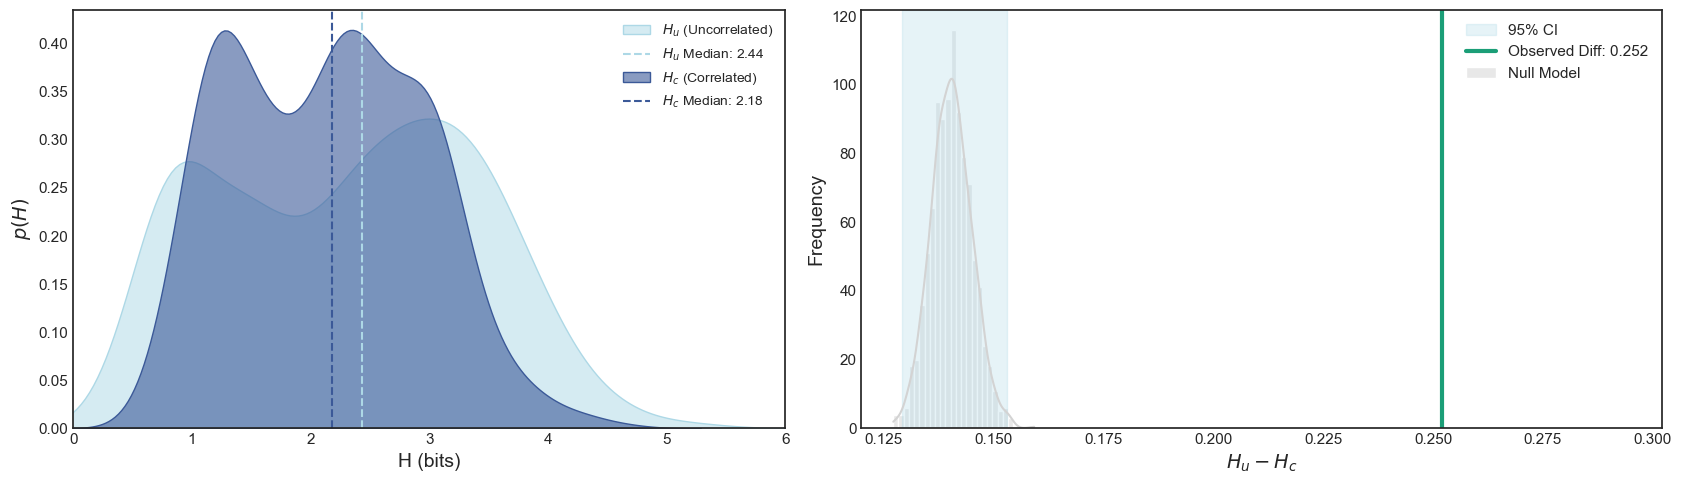


--- RESULTADOS DEL MODELO NULO ---
95% Confidence Interval: [0.12921, 0.15313]
Diferencia Observada Real: 0.2521
p-value: 0.000000


In [32]:
entropy_comparison = pd.DataFrame({'Hu': hu_values, 'Hc': results_hc}).dropna()
obs_diff_global = 0.2521388561149407
null_diffs_trajectory = []
n_permutations = 1000

print("Iniciando Shuffling de trayectorias con Intervalo de Confianza...")

for i in range(n_permutations):
    shuffled_checkins = checkins.copy()
    shuffled_checkins['POI_id'] = shuffled_checkins.groupby(['user_id', 'mov_day'])['POI_id'].transform(np.random.permutation)
    
    daily_entropy_null = shuffled_checkins.groupby(['user_id', 'mov_day'])['POI_id'].apply(list).reset_index()
    daily_entropy_null = daily_entropy_null[daily_entropy_null['POI_id'].apply(lambda x: len(set(x)) > 1)]
    daily_entropy_null['Hu_val'] = daily_entropy_null['POI_id'].apply(compute_hu)
    user_hu_null = daily_entropy_null.groupby('user_id')['Hu_val'].mean()
    
    daily_hc_null = shuffled_checkins.groupby(['user_id', 'mov_day'])['POI_id'].apply(list).reset_index()
    daily_hc_null = daily_hc_null[daily_hc_null['POI_id'].apply(lambda x: len(set(x)) > 1)]
    daily_hc_null['Hc_val'] = daily_hc_null['POI_id'].apply(compute_hc)
    user_hc_null = daily_hc_null.groupby('user_id')['Hc_val'].mean()
    
    null_diff = (user_hu_null - user_hc_null).mean()
    null_diffs_trajectory.append(null_diff)

null_diffs_trajectory = np.array(null_diffs_trajectory)

ci_low_traj = np.percentile(null_diffs_trajectory, 0.5)
ci_high_traj = np.percentile(null_diffs_trajectory, 99.5)
p_val_trajectory = np.mean(null_diffs_trajectory >= obs_diff_global)

fig, axs = plt.subplots(1, 2, figsize=(17, 5), gridspec_kw={'width_ratios': [8, 9]})
cmap = plt.get_cmap('Dark2')

sns.kdeplot(entropy_comparison['Hu'], fill=True, color='lightblue', label='$H_u$ (Uncorrelated)', alpha=0.5, ax=axs[0])
axs[0].axvline(entropy_comparison['Hu'].median(), color='lightblue', linestyle='--', linewidth=1.5, label=f"$H_u$ Median: {entropy_comparison['Hu'].median():.2f}")
sns.kdeplot(entropy_comparison['Hc'], fill=True, color='#3b5998', label='$H_c$ (Correlated)', alpha=0.6, ax=axs[0])
axs[0].axvline(entropy_comparison['Hc'].median(), color='#3b5998', linestyle='--', linewidth=1.5, label=f"$H_c$ Median: {entropy_comparison['Hc'].median():.2f}")
axs[0].set_xlabel('H (bits)', fontsize=14)
axs[0].set_ylabel('$p(H)$', fontsize=14)
axs[0].set_xlim(0, 6) 
axs[0].legend(frameon=False, fontsize=10)
axs[0].tick_params(axis='both', length=0)

sns.histplot(null_diffs_trajectory, kde=True, color='lightgray', edgecolor='white', label='Null Model', ax=axs[1])
axs[1].axvspan(ci_low_traj, ci_high_traj, color='lightblue', alpha=0.3, label='95% CI')
axs[1].axvline(obs_diff_global, color=cmap(0), lw=3, linestyle='-', label=f'Observed Diff: {obs_diff_global:.3f}')
axs[1].axvline(0, color='black', lw=1, linestyle='--')
y_max = axs[1].get_ylim()[1]
x_range = max(abs(null_diffs_trajectory.min()), abs(null_diffs_trajectory.max()), abs(obs_diff_global)) * 1.2
axs[1].set_xlim(0.12, obs_diff_global+0.05)
axs[1].set_ylim(0, y_max)
axs[1].set_xlabel(r'$ H_u - H_c $', fontsize=14)
axs[1].set_ylabel('Frequency', fontsize=14)
axs[1].tick_params(axis='both', length=0)
axs[1].legend(frameon=False, fontsize=11, loc='upper right')

plt.tight_layout()
#plt.savefig('figs/entropy_and_shuffling_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"\n--- RESULTADOS DEL MODELO NULO ---")
print(f"95% Confidence Interval: [{ci_low_traj:.5f}, {ci_high_traj:.5f}]")
print(f"Diferencia Observada Real: {obs_diff_global:.4f}")
print(f"p-value: {p_val_trajectory:.6f}")

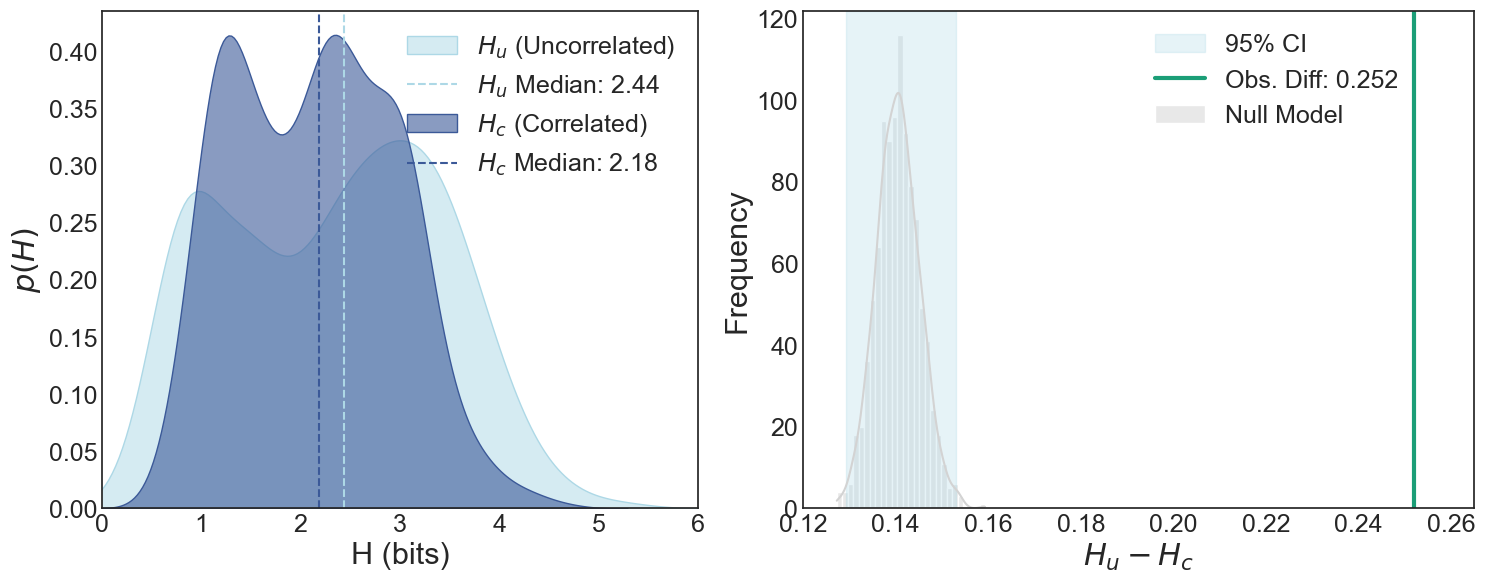


--- RESULTADOS DEL MODELO NULO ---
95% Confidence Interval: [0.12921, 0.15313]
Diferencia Observada Real: 0.2521
p-value: 0.000000


In [40]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [8, 9]})
cmap = plt.get_cmap('Dark2')

sns.kdeplot(entropy_comparison['Hu'], fill=True, color='lightblue', label='$H_u$ (Uncorrelated)', alpha=0.5, ax=axs[0])
axs[0].axvline(entropy_comparison['Hu'].median(), color='lightblue', linestyle='--', linewidth=1.5, label=f"$H_u$ Median: {entropy_comparison['Hu'].median():.2f}")
sns.kdeplot(entropy_comparison['Hc'], fill=True, color='#3b5998', label='$H_c$ (Correlated)', alpha=0.6, ax=axs[0])
axs[0].axvline(entropy_comparison['Hc'].median(), color='#3b5998', linestyle='--', linewidth=1.5, label=f"$H_c$ Median: {entropy_comparison['Hc'].median():.2f}")
axs[0].set_xlabel('H (bits)', fontsize=22)
axs[0].set_ylabel('$p(H)$', fontsize=22)
axs[0].set_xlim(0, 6) 
axs[0].legend(frameon=False, fontsize=18)
axs[0].tick_params(axis='both', length=0, labelsize=18)

sns.histplot(null_diffs_trajectory, kde=True, color='lightgray', edgecolor='white', label='Null Model', ax=axs[1])
axs[1].axvspan(ci_low_traj, ci_high_traj, color='lightblue', alpha=0.3, label='95% CI')
axs[1].axvline(obs_diff_global, color=cmap(0), lw=3, linestyle='-', label=f'Obs. Diff: {obs_diff_global:.3f}')
axs[1].axvline(0, color='black', lw=1, linestyle='--')
y_max = axs[1].get_ylim()[1]
x_range = max(abs(null_diffs_trajectory.min()), abs(null_diffs_trajectory.max()), abs(obs_diff_global)) * 1.2
axs[1].set_xlim(0.12, 0.265)
axs[1].set_ylim(0, y_max)
axs[1].set_xlabel(r'$ H_u - H_c $', fontsize=22)
axs[1].set_ylabel('Frequency', fontsize=22)
axs[1].tick_params(axis='both', length=0, labelsize=18)
# bbox_to_anchor=(x, y) -> bajar la x de 1.0 a 0.85 la mueve a la izquierda
axs[1].legend(frameon=False, fontsize=18, loc='upper right', bbox_to_anchor=(0.92, 1.0))

plt.tight_layout()
plt.savefig('entropy_and_shuffling_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"\n--- RESULTADOS DEL MODELO NULO ---")
print(f"95% Confidence Interval: [{ci_low_traj:.5f}, {ci_high_traj:.5f}]")
print(f"Diferencia Observada Real: {obs_diff_global:.4f}")
print(f"p-value: {p_val_trajectory:.6f}")

bien!!!!! per la correlated hi ha mes densitat de probabilitat a entropies menors

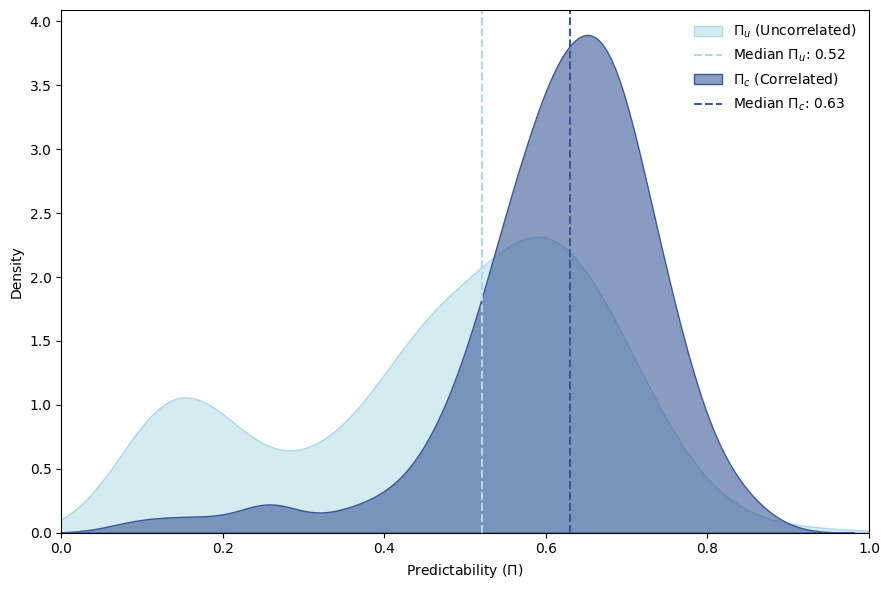

In [ ]:
daily_S = checkins.groupby(['user_id', 'mov_day'])['POI_id'].nunique().reset_index()
avg_S_per_user = daily_S.groupby('user_id')['POI_id'].mean()

def to_clean_series(data):
    if isinstance(data, pd.DataFrame):
        return data.iloc[:, 0]
    return data

hu_series = to_clean_series(hu_values)
hc_series = to_clean_series(results_hc)
if isinstance(hu_series.index, pd.MultiIndex):
    hu_series = hu_series.groupby(level='user_id').mean()
if isinstance(hc_series.index, pd.MultiIndex):
    hc_series = hc_series.groupby(level='user_id').mean()

predict_input = pd.DataFrame({'Hu': hu_series,'Hc': hc_series,'S_avg': avg_S_per_user}).dropna()
predictability_results = []
for uid, row in predict_input.iterrows():
    s = row['S_avg']
    if s > 1:
        pi_u = calculate_predictability(row['Hu'], s)
        pi_c = calculate_predictability(row['Hc'], s)
        predictability_results.append({'user_id': uid, 'Pi_u': pi_u,  'Pi_c': pi_c})

predictability_df = pd.DataFrame(predictability_results)

plt.figure(figsize=(9, 6))
sns.kdeplot(predictability_df['Pi_u'], fill=True, color='lightblue', label='$\Pi_u$ (Uncorrelated)', alpha=0.5)
plt.axvline(predictability_df['Pi_u'].median(), color='lightblue', linestyle='--', label=f'Median $\Pi_u$: {predictability_df["Pi_u"].median():.2f}')

sns.kdeplot(predictability_df['Pi_c'], fill=True, color='#3b5998', label='$\Pi_c$ (Correlated)', alpha=0.6)
plt.axvline(predictability_df['Pi_c'].median(), color='#3b5998', linestyle='--', label=f'Median $\Pi_c$: {predictability_df["Pi_c"].median():.2f}')

per la correlated la predictabilitat es major!! tops

## window of observation

no tiene sentido!! si un usuario solo visita una localizacion en una hora la predictabilidad no tiene sentido. vamos a hacer lo mismo excluyendo usuarios que no se mueven en el time slot o ampliando la ventana de observacion

# CATEGORIES OF POIS

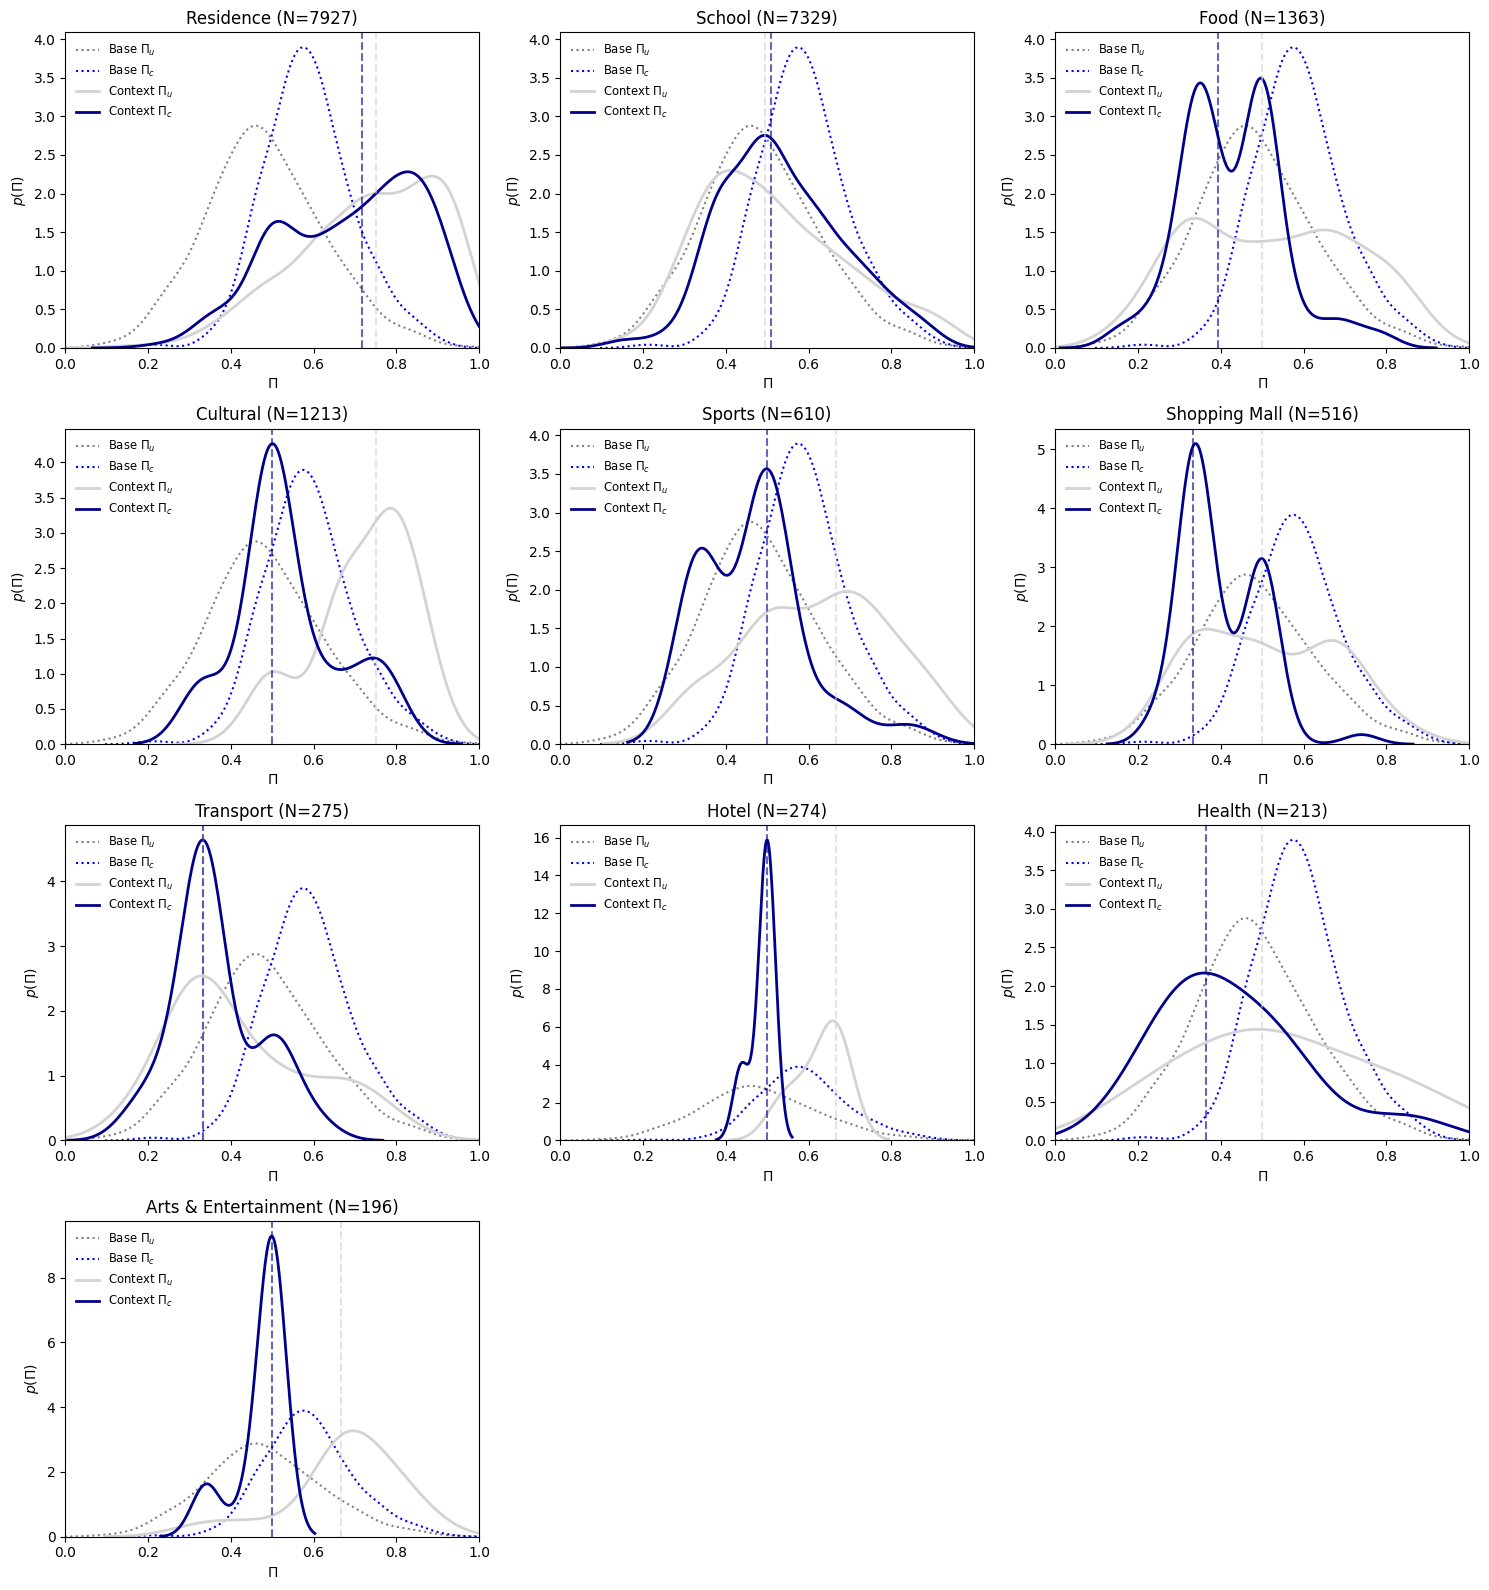

In [116]:
def plot_refined_mobility_grid(df, min_checkins=150):
    baseline_list = []
    for _, group in df.groupby('user_id'):
        seq = group['POI_id'].tolist()
        s = len(set(seq))
        if s > 1:
            hu = compute_hu(seq)
            hc = compute_hc(seq)
            baseline_list.append({'pi_u': calculate_predictability(hu, s),'pi_c': calculate_predictability(hc, s) })
    df_baseline = pd.DataFrame(baseline_list)

    cat_counts = df['POI_category'].value_counts()
    valid_categories = cat_counts[cat_counts >= min_checkins].index.tolist()
    n_cats = len(valid_categories)
    cols = 3
    rows = math.ceil(n_cats / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()
    for i, cat in enumerate(valid_categories):
        cat_results = []
        cat_df = df[df['POI_category'] == cat]
        
        for _, user_data in cat_df.groupby('user_id'):
            seq = user_data['POI_id'].tolist()
            s = len(set(seq))
            if s > 1 and len(seq) >= 3:
                hu = compute_hu(seq)
                hc = compute_hc(seq)
                cat_results.append({'pi_u': calculate_predictability(hu, s),'pi_c': calculate_predictability(hc, s)})
        df_cat = pd.DataFrame(cat_results)
        ax = axes[i]
        
        sns.kdeplot(df_baseline['pi_u'], color='gray', ls=':', ax=ax, label='Base $\Pi_u$')
        sns.kdeplot(df_baseline['pi_c'], color='blue', ls=':', ax=ax, label='Base $\Pi_c$')
        if len(df_cat) > 1 and df_cat['pi_c'].nunique() > 1:
            sns.kdeplot(df_cat['pi_u'], color='lightgray', lw=2, ax=ax, label=f'Context $\Pi_u$')
            sns.kdeplot(df_cat['pi_c'], color='darkblue', lw=2, ax=ax, label=f'Context $\Pi_c$')
            ax.axvline(df_cat['pi_u'].median(), color='lightgray', ls='--', alpha=0.6)
            ax.axvline(df_cat['pi_c'].median(), color='darkblue', ls='--', alpha=0.6)
        else:
            ax.text(0.5, 0.5, 'not enough data', 
                    ha='center', va='center', transform=ax.transAxes, color='red')

        ax.set_title(f"{cat} (N={cat_counts[cat]})")
        ax.set_xlim(0, 1)
        ax.set_xlabel("$\Pi$")
        ax.set_ylabel("$p(\Pi)$")
        ax.legend(loc='upper left', fontsize='small', frameon=False)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

plot_refined_mobility_grid(checkins, min_checkins=150)

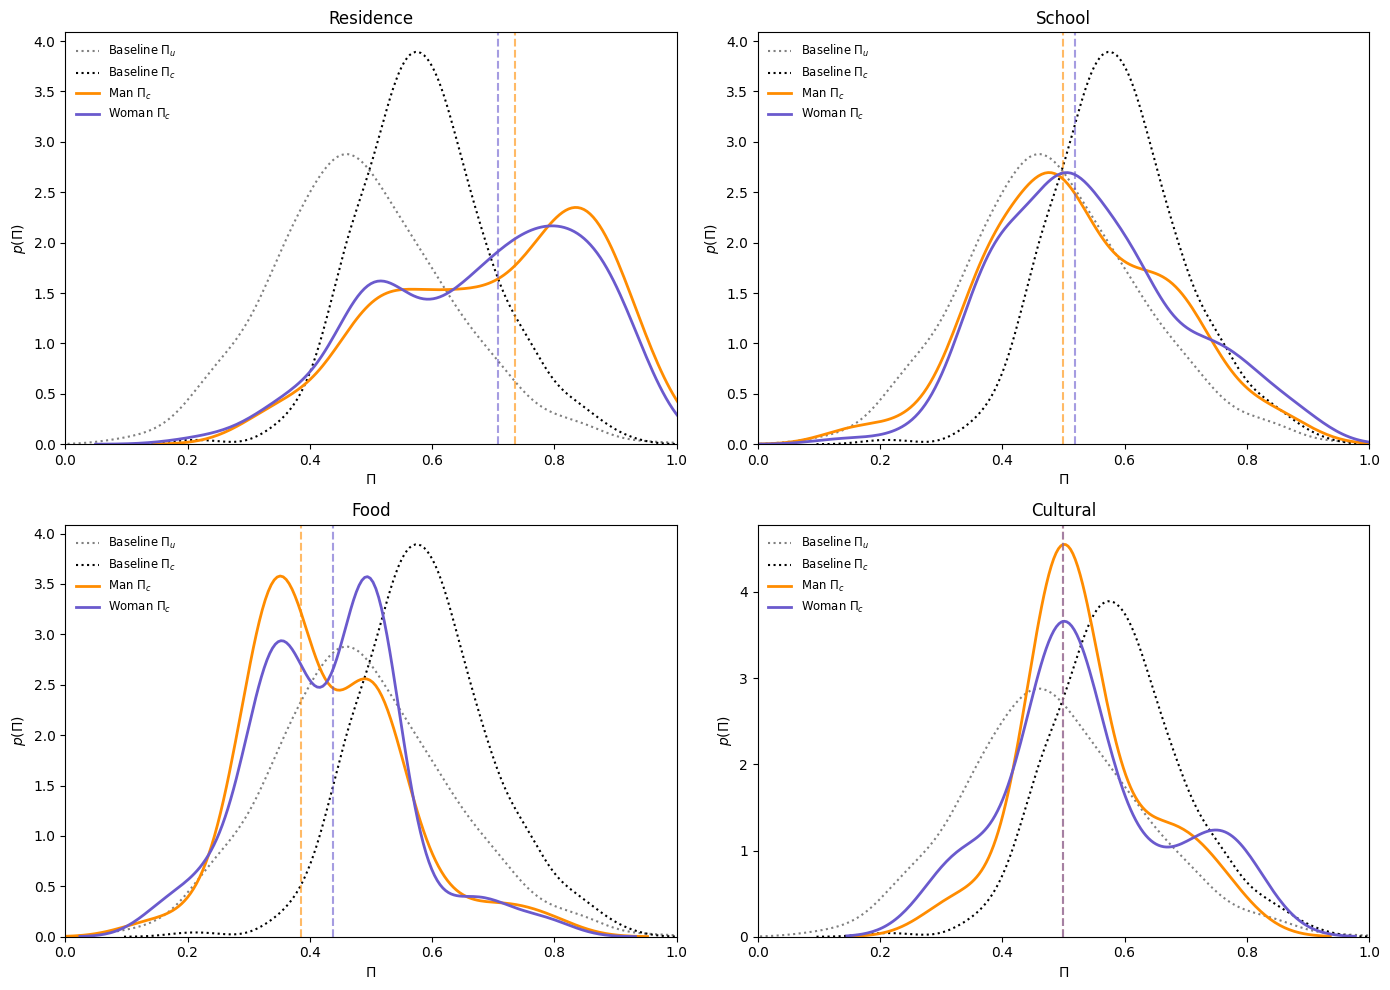

In [119]:
def plot_gender_comparison_grid(df, target_categories=['Residence', 'School', 'Food', 'Cultural']):
    baseline_list = []
    for _, group in df.groupby('user_id'):
        seq = group['POI_id'].tolist()
        s = len(set(seq))
        if s > 1:
            hu = compute_hu(seq)
            hc = compute_hc(seq)
            baseline_list.append({ 'pi_u': calculate_predictability(hu, s),'pi_c': calculate_predictability(hc, s) })
    df_baseline = pd.DataFrame(baseline_list)
    n_cats = len(target_categories)
    cols = 2
    rows = math.ceil(n_cats / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5))
    axes = axes.flatten()
    gender_map = {0: {'label': 'Man', 'color': 'darkorange'}, 1: {'label': 'Woman', 'color': 'slateblue'}}

    for i, cat in enumerate(target_categories):
        cat_df = df[df['POI_category'] == cat]
        ax = axes[i]
        sns.kdeplot(df_baseline['pi_u'], color='gray', ls=':', ax=ax, label='Baseline $\Pi_u$')
        sns.kdeplot(df_baseline['pi_c'], color='black', ls=':', ax=ax, label='Baseline $\Pi_c$')
        for gender_val in [0, 1]:
            gender_data = cat_df[cat_df['gender'] == gender_val]
            gender_results = []
            
            for _, user_data in gender_data.groupby('user_id'):
                seq = user_data['POI_id'].tolist()
                s = len(set(seq))
                if s > 1 and len(seq) >= 3:
                    hu = compute_hu(seq)
                    hc = compute_hc(seq)
                    gender_results.append({'pi_u': calculate_predictability(hu, s),'pi_c': calculate_predictability(hc, s) })
            df_gender = pd.DataFrame(gender_results)
            
            if not df_gender.empty and df_gender['pi_c'].nunique() > 1:
                config = gender_map[gender_val]
                sns.kdeplot(df_gender['pi_c'], lw=2, ax=ax,  label=f"{config['label']} $\Pi_c$", color=config['color'])
                ax.axvline(df_gender['pi_c'].median(), ls='--', alpha=0.6, color=config['color'])

        ax.set_title(f"{cat}")
        ax.set_xlim(0, 1)
        ax.set_xlabel("$\Pi$")
        ax.set_ylabel("$p(\Pi)$")
        ax.legend(loc='upper left', fontsize='small', frameon=False)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.savefig('genderpois.png')
    plt.show()


plot_gender_comparison_grid(checkins)

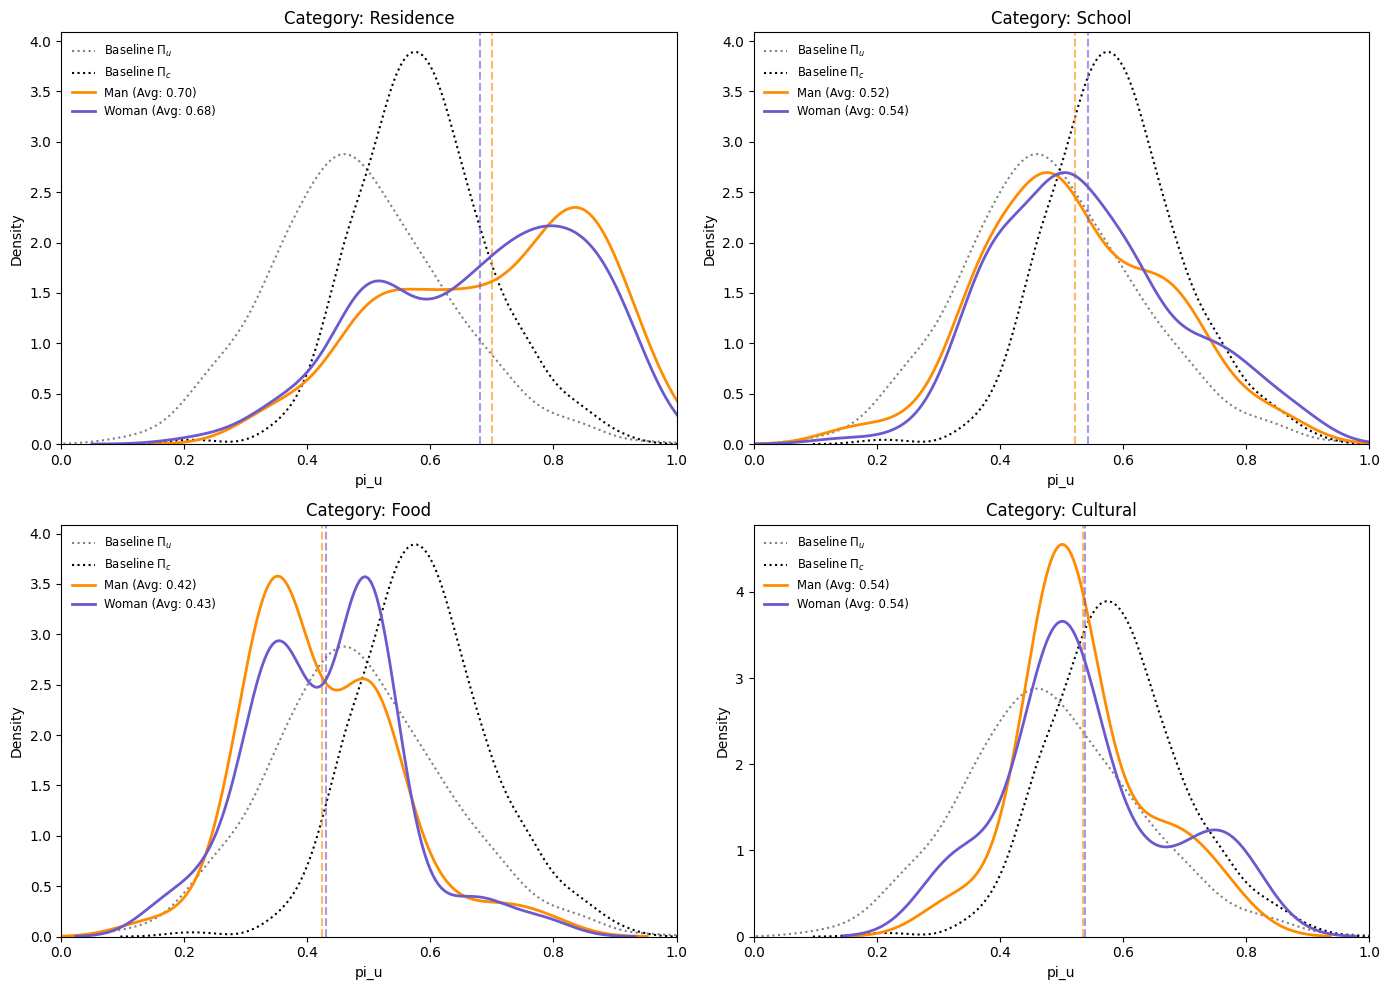

    Category Gender  Mean_Pi_c  Skewness_Pi_c  Count
0  Residence    Man   0.700233      -0.404116    126
1  Residence  Woman   0.680947      -0.389913    210
2     School    Man   0.522735       0.144277    155
3     School  Woman   0.543210       0.360464    284
4       Food    Man   0.423676       0.740450     55
5       Food  Woman   0.430608       0.321809    104
6   Cultural    Man   0.535730       0.549751     15
7   Cultural  Woman   0.538421       0.426313     43


In [93]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew # Importante para la asimetría

def plot_gender_comparison_with_stats(df, target_categories=['Residence', 'School', 'Food', 'Cultural']):
    stats_list = []  # Para guardar los resultados numéricos
    
    # 1. Cálculo del Baseline (Población total)
    baseline_list = []
    for _, group in df.groupby('user_id'):
        seq = group['POI_id'].tolist()
        s = len(set(seq))
        if s > 1:
            hu = compute_hu(seq)
            hc = compute_hc(seq)
            baseline_list.append({
                'pi_u': calculate_predictability(hu, s),
                'pi_c': calculate_predictability(hc, s)
            })
    df_baseline = pd.DataFrame(baseline_list)

    n_cats = len(target_categories)
    cols = 2
    rows = math.ceil(n_cats / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5))
    axes = axes.flatten()
    
    gender_map = {
        0: {'label': 'Man', 'color': 'darkorange'}, 
        1: {'label': 'Woman', 'color': 'slateblue'}
    }

    for i, cat in enumerate(target_categories):
        cat_df = df[df['POI_category'] == cat]
        ax = axes[i]
        
        # Dibujar Baselines
        sns.kdeplot(df_baseline['pi_u'], color='gray', ls=':', ax=ax, label='Baseline $\Pi_u$')
        sns.kdeplot(df_baseline['pi_c'], color='black', ls=':', ax=ax, label='Baseline $\Pi_c$')

        for gender_val in [0, 1]:
            gender_data = cat_df[cat_df['gender'] == gender_val]
            gender_results = []
            
            for _, user_data in gender_data.groupby('user_id'):
                seq = user_data['POI_id'].tolist()
                s = len(set(seq))
                if s > 1 and len(seq) >= 3:
                    hu = compute_hu(seq)
                    hc = compute_hc(seq)
                    gender_results.append({
                        'pi_c': calculate_predictability(hc, s)
                    })
            
            df_gender = pd.DataFrame(gender_results)
            
            if not df_gender.empty and df_gender['pi_c'].nunique() > 1:
                config = gender_map[gender_val]
                
                # --- CÁLCULO DE MÉTRICAS ---
                m_val = df_gender['pi_c'].mean()
                s_val = skew(df_gender['pi_c'].dropna())
                
                # Guardamos en nuestra lista de stats
                stats_list.append({
                    'Category': cat,
                    'Gender': config['label'],
                    'Mean_Pi_c': m_val,
                    'Skewness_Pi_c': s_val,
                    'Count': len(df_gender)
                })

                # Visualización
                sns.kdeplot(df_gender['pi_c'], lw=2, ax=ax, 
                            label=f"{config['label']} (Avg: {m_val:.2f})", 
                            color=config['color'])
                ax.axvline(m_val, ls='--', alpha=0.6, color=config['color'])

        ax.set_title(f"Category: {cat}")
        ax.set_xlim(0, 1)
        ax.legend(loc='upper left', fontsize='small', frameon=False)

    plt.tight_layout()
    plt.show()

    # Retornamos un DataFrame con el resumen para que puedas analizarlo
    return pd.DataFrame(stats_list)

# Ejecución
df_resumen_stats = plot_gender_comparison_with_stats(checkins)
print(df_resumen_stats)

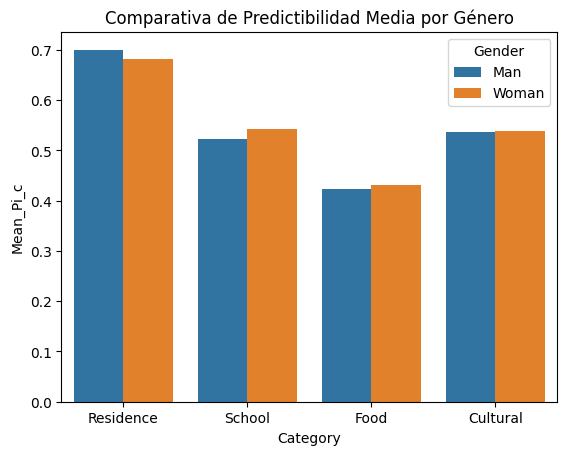

In [94]:
sns.barplot(data=df_resumen_stats, x='Category', y='Mean_Pi_c', hue='Gender')
plt.title("Comparativa de Predictibilidad Media por Género")
plt.show()

WAVELET TRANSFROM. aixo es per veure quin dels cicles te mes importancia en la predictabilitat

C:\Users\34633\AppData\Local\Temp\ipykernel_5864\3473675790.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  checkins_filt['time'] = pd.to_datetime(checkins_filt['time'])


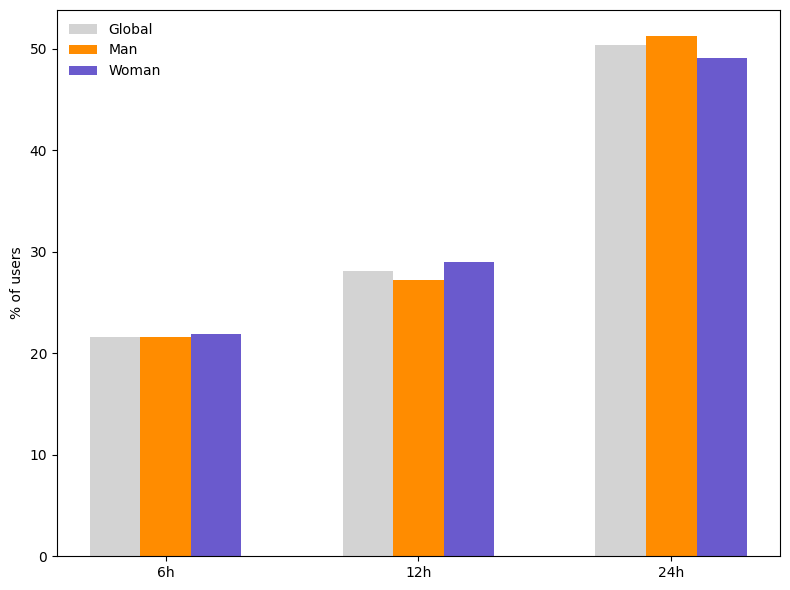

In [95]:
S_total = checkins.groupby('user_id')['POI_id'].nunique()
usuarios_activos = S_total[S_total >= 5].index
checkins_filt = checkins[checkins['user_id'].isin(usuarios_activos)].copy()

checkins_filt['time'] = pd.to_datetime(checkins_filt['time'])
checkins_filt['hour'] = checkins_filt['time'].dt.hour
checkins_filt['timeslot'] = (checkins_filt['day_of_week'] - 1) * 24 + checkins_filt['hour']

periodic_results = []
for (slot, uid), group in checkins_filt.groupby(['timeslot', 'user_id']):
    if len(group) < 2: continue
    h_u_t = compute_hu(group['POI_id'].tolist())
    s_val = S_total[uid]
    if s_val > 1:
        pi_val = calculate_predictability(h_u_t, s_val)
        gender_val = group['gender'].iloc[0]
        periodic_results.append({'timeslot': slot, 'user_id': uid, 'pi': pi_val, 'gender': gender_val})
df_pi_t = pd.DataFrame(periodic_results)

def analyze_frequencies(df_input):
    if df_input.empty: return None, None, None
    pi_matrix = df_input.pivot(index='user_id', columns='timeslot', values='pi')
    pi_matrix = pi_matrix.apply(lambda row: row.fillna(row.mean()), axis=1).dropna()
    if pi_matrix.empty: return None, None, None
    avg_signal = pi_matrix.mean(axis=0).values
    n = len(avg_signal)
    yf = fft(avg_signal - np.mean(avg_signal))
    xf = fftfreq(n, 1) 
    periods = 1 / xf[1:n//2] 
    power = np.abs(yf[1:n//2])**2
    user_modes = []
    for uid in pi_matrix.index:
        u_sig = pi_matrix.loc[uid].values
        u_yf = fft(u_sig - np.mean(u_sig))
        u_pow = np.abs(u_yf[1:n//2])**2
        idx24 = np.argmin(np.abs(periods - 24))
        idx12 = np.argmin(np.abs(periods - 12))
        idx6 = np.argmin(np.abs(periods - 6))
        pvals = {'24h': u_pow[idx24], '12h': u_pow[idx12], '6h': u_pow[idx6]}
        user_modes.append(max(pvals, key=pvals.get))
    return periods, power, user_modes

p_all, pow_all, m_all = analyze_frequencies(df_pi_t)
p_man, pow_man, m_man = analyze_frequencies(df_pi_t[df_pi_t['gender'] == 0])
p_woman, pow_woman, m_woman = analyze_frequencies(df_pi_t[df_pi_t['gender'] == 1])

def get_dist(modes):
    if not modes: return [0, 0, 0]
    s = pd.Series(modes).value_counts(normalize=True) * 100
    return [s.get('6h', 0), s.get('12h', 0), s.get('24h', 0)]

fig, ax = plt.subplots(figsize=(8, 6))
labels = ['6h', '12h', '24h']
x = np.arange(len(labels))

ax.bar(x - 0.2, get_dist(m_all), 0.2, label='Global', color='lightgray')
ax.bar(x, get_dist(m_man), 0.2, label='Man', color='darkorange')
ax.bar(x + 0.2, get_dist(m_woman), 0.2, label='Woman', color='slateblue')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('% of users')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## DISTRIBUTION OF LOGINS

C:\Users\34633\AppData\Local\Temp\ipykernel_36412\2677616357.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  login['hour'] = pd.to_datetime(login['time'], errors='coerce').dt.hour


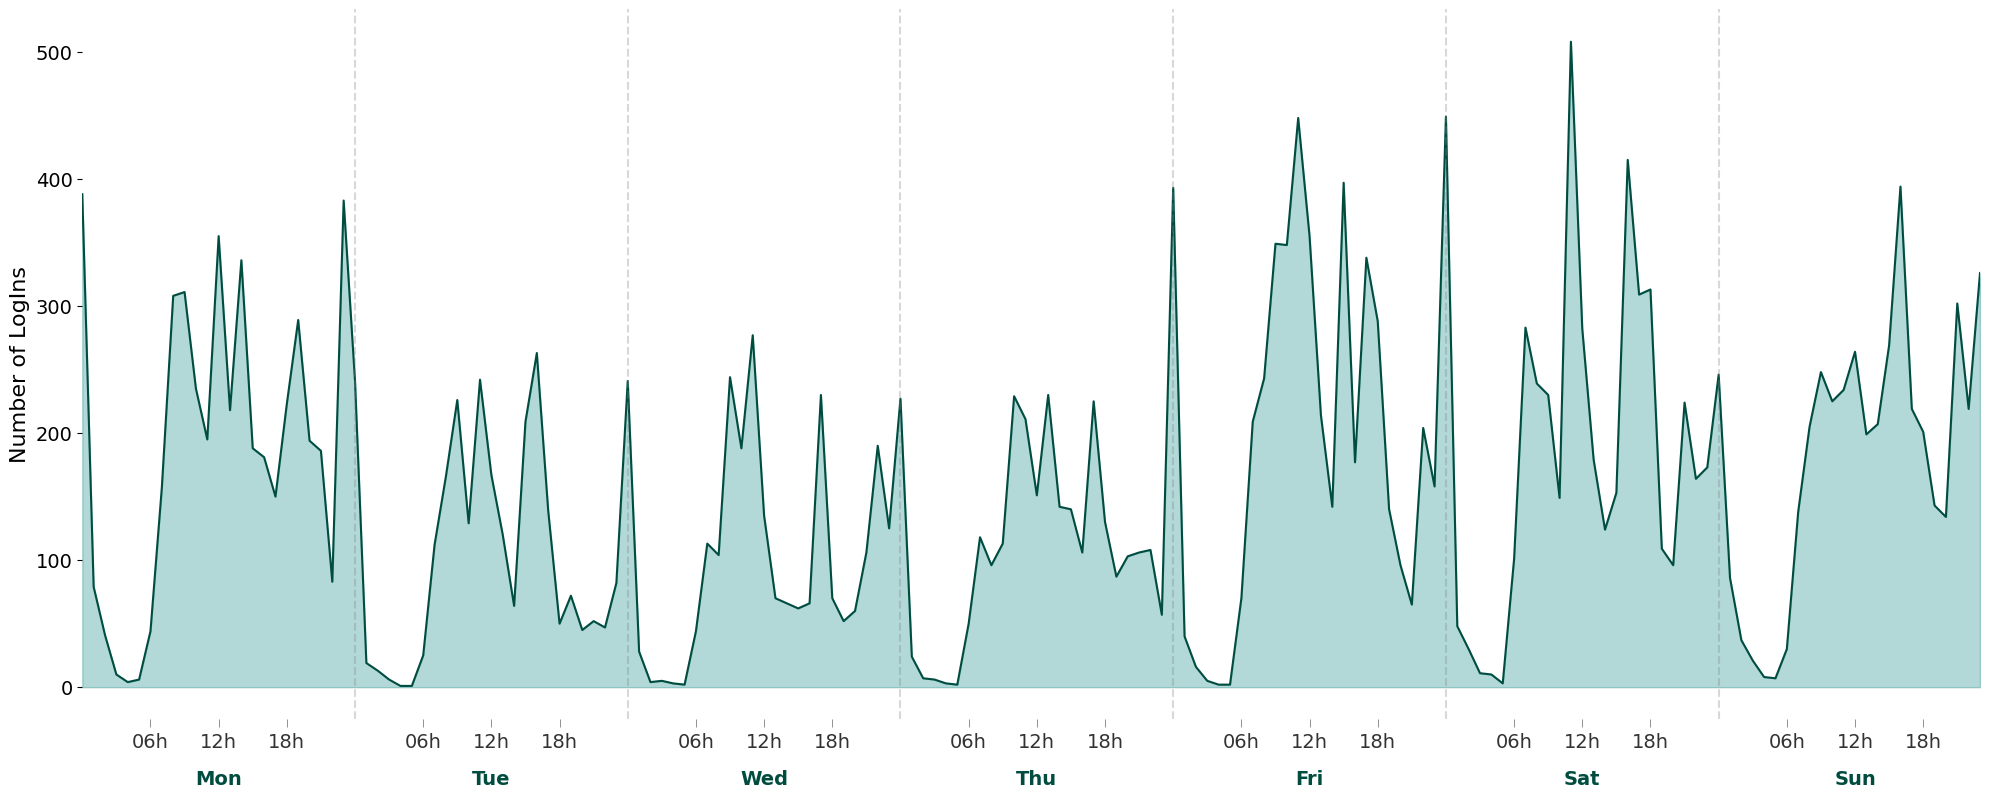

In [2]:
column_names = ['user_id', 'day', 'day_of_week', 'time']
login = pd.read_csv('/Users/34633/Documents/master/tfm/data/chinadata/login.csv', sep=',', encoding='latin1', header=None, names=column_names)

login['hour'] = pd.to_datetime(login['time'], errors='coerce').dt.hour
login['timeslot'] = (login['day_of_week'] - 1) * 24 + login['hour']

counts = login.groupby('timeslot').size().reindex(range(168), fill_value=0)

plt.figure(figsize=(20, 8))
ax = plt.gca()

plt.plot(counts.index, counts.values, color='#004d40', linewidth=1.5)
plt.fill_between(counts.index, counts.values, color='#008080', alpha=0.3)

for spine in ax.spines.values():
    spine.set_visible(False)

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
major_pos = np.arange(0, 169, 24)
minor_pos = np.arange(0, 168, 6)
minor_labels = [f'{h:02d}h' if h != 0 else '' for h in (list(range(0, 24, 6)) * 7)]

ax.set_xticks(major_pos)
ax.set_xticklabels(['' for _ in major_pos])

for i, day in enumerate(days):
    ax.text(i * 24 + 12, -max(counts.values) * 0.15, day, ha='center', fontweight='bold', color='#004d40', fontsize=14)

ax.set_xticks(minor_pos, minor=True)
ax.set_xticklabels(minor_labels, minor=True, fontsize=14, alpha=0.8)

for i in range(24, 168, 24):
    plt.axvline(x=i, color='gray', linestyle='--', alpha=0.3)

plt.ylabel('Number of LogIns', fontsize=16)
plt.xlim(0, 167)
plt.grid(False)
plt.tick_params(axis='y', labelsize=14)
plt.tick_params(axis='x', which='major', length=0)
plt.tick_params(axis='x', which='minor', length=6, color='gray')

plt.tight_layout()
plt.savefig('figs/login.png', bbox_inches='tight', dpi=300)
plt.show()

mean distance between peaks by day
day_of_week
Mon    4.609723
Tue    3.940692
Wed    4.867466
Thu    3.956152
Fri    4.003853
Sat    4.572660
Sun    4.567691
dtype: float64

GLOBAL mean of distance between peaks: 4.36 hours


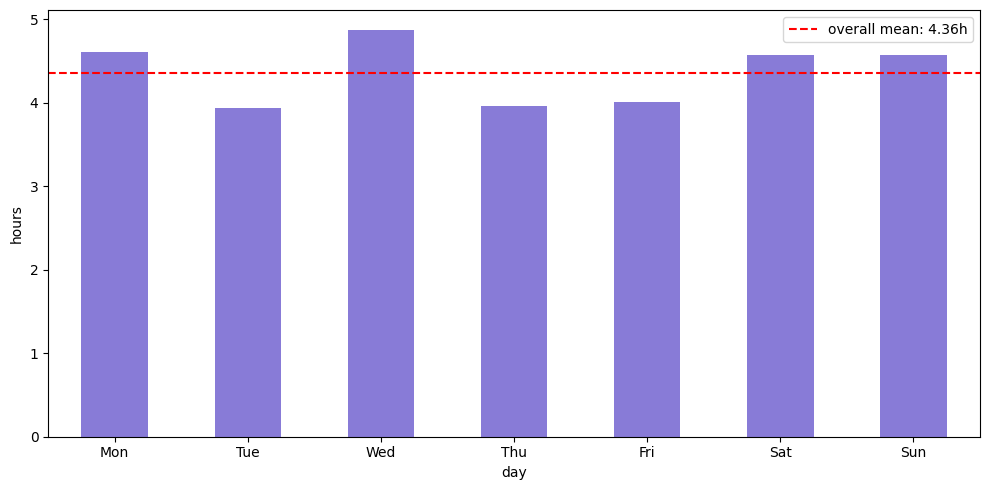

In [97]:

activity = login.groupby(['day', 'day_of_week', 'user_id', 'hour']).size().unstack(fill_value=0).reindex(columns=range(24), fill_value=0)

def calculate_peak_dist(row):
    peaks, _ = find_peaks(row.values, height=0)
    if len(peaks) > 1:
        return np.diff(peaks).mean()
    return np.nan

user_day_results = activity.apply(calculate_peak_dist, axis=1)
daily_date_averages = user_day_results.groupby(level=['day', 'day_of_week']).mean()
dow_averages = daily_date_averages.groupby(level='day_of_week').mean()

days_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
dow_averages.index = dow_averages.index.map(days_map)
global_average = dow_averages.mean()

print("mean distance between peaks by day")
print(dow_averages)
print(f"\nGLOBAL mean of distance between peaks: {global_average:.2f} hours")


plt.figure(figsize=(10, 5))
dow_averages.plot(kind='bar', color='slateblue', alpha=0.8)
plt.ylabel('hours')
plt.xlabel('day')
plt.xticks(rotation=0)
plt.axhline(y=global_average, color='red', linestyle='--', label=f'overall mean: {global_average:.2f}h')
plt.legend()
plt.tight_layout()
plt.show()

Mean distance between peaks by day (starting after dawn)
day_of_week
Mon    4.431779
Tue    3.862426
Wed    4.786390
Thu    3.882189
Fri    3.907981
Sat    4.435474
Sun    4.309804
dtype: float64

GLOBAL mean: 4.23 hours


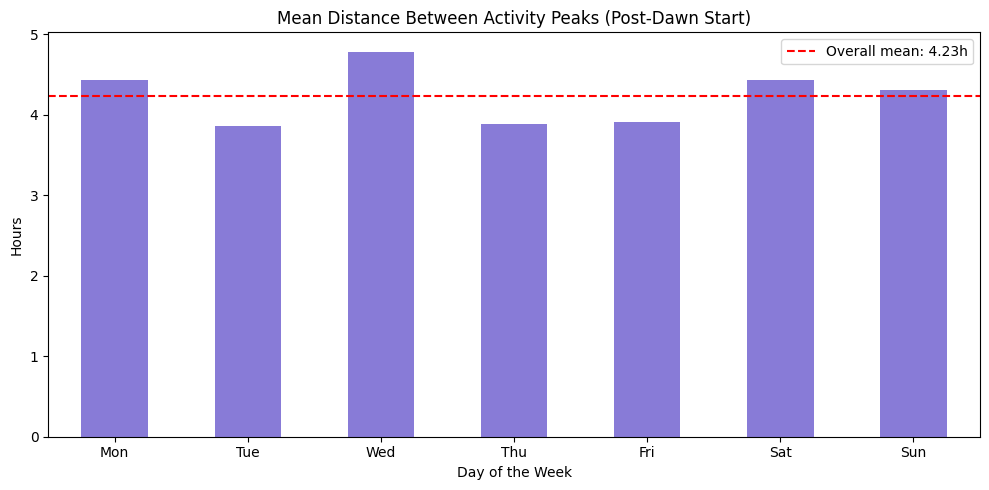

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

MORNING_THRESHOLD = 5

def calculate_morning_peak_dist(row):
    peaks, _ = find_peaks(row.values, height=0)
    morning_peaks = [p for p in peaks if p >= MORNING_THRESHOLD]
    
    if len(morning_peaks) > 1:
        return np.diff(morning_peaks).mean()
    return np.nan

activity = login.groupby(['day', 'day_of_week', 'user_id', 'hour']).size().unstack(fill_value=0).reindex(columns=range(24), fill_value=0)

user_day_results = activity.apply(calculate_morning_peak_dist, axis=1)
daily_date_averages = user_day_results.groupby(level=['day', 'day_of_week']).mean()
dow_averages = daily_date_averages.groupby(level='day_of_week').mean()

days_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
dow_averages.index = dow_averages.index.map(days_map)
global_average = dow_averages.mean()

print("Mean distance between peaks by day (starting after dawn)")
print(dow_averages)
print(f"\nGLOBAL mean: {global_average:.2f} hours")

plt.figure(figsize=(10, 5))
dow_averages.plot(kind='bar', color='slateblue', alpha=0.8)
plt.ylabel('Hours')
plt.xlabel('Day of the Week')
plt.xticks(rotation=0)
plt.axhline(y=global_average, color='red', linestyle='--', label=f'Overall mean: {global_average:.2f}h')
plt.title('Mean Distance Between Activity Peaks (Post-Dawn Start)')
plt.legend()
plt.tight_layout()
plt.savefig('peak_distances.png')

Elimina sesgos de "Heavy Users": Si un usuario tiene 50 picos en un día y otro solo 2, el promedio simple daría mucha más importancia al primero. Al promediar primero por usuario, cada individuo aporta un solo dato a la estadística del día.

# power law

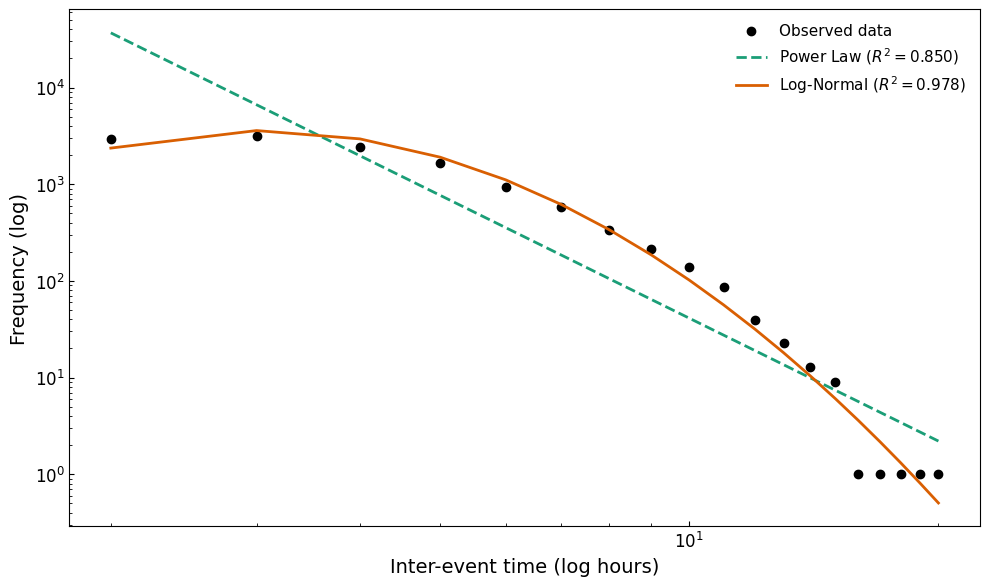

In [109]:
all_distances = []
for _, row in activity.iterrows():
    peaks, _ = find_peaks(row.values, height=0)
    if len(peaks) > 1:
        all_distances.extend(np.diff(peaks))

dist_counts = pd.Series(all_distances).value_counts().sort_index()
x_data = dist_counts.index.values.astype(float)
y_data = dist_counts.values.astype(float)

mask = x_data <= 24
x_data = x_data[mask]
y_data = y_data[mask]

log_x = np.log10(x_data)
log_y = np.log10(y_data)

p_pl = np.polyfit(log_x, log_y, 1)
y_fit_pl = 10**np.polyval(p_pl, log_x)
r2_pl = r2_score(log_y, np.polyval(p_pl, log_x))

p_ln = np.polyfit(log_x, log_y, 2)
y_fit_ln = 10**np.polyval(p_ln, log_x)
r2_ln = r2_score(log_y, np.polyval(p_ln, log_x))

cmap = plt.get_cmap('Dark2')
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data,label='Observed data', color = 'black')
plt.plot(x_data, y_fit_pl, color=cmap(0), lw=2, linestyle='--', label=f'Power Law ($R^2={r2_pl:.3f}$)')
plt.plot(x_data, y_fit_ln, color=cmap(1), lw=2, label=f'Log-Normal ($R^2={r2_ln:.3f}$)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Inter-event time (log hours)', fontsize=14)
plt.ylabel('Frequency (log)', fontsize=14)
plt.grid(False)
plt.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.tick_params(axis='both', direction='in', which='major', labelsize=12)
plt.tick_params(axis='both', direction='in', which='minor', labelsize=12)
plt.savefig('figs/eq_logintimes.png', dpi=300)
plt.show()

In [99]:
# Parámetros Power Law
alpha = -p_pl[0]
intercept_pl = 10**p_pl[1]

# Parámetros Log-Normal (del polinomio)
A, B, C_ln = p_ln

print(f"--- PARÁMETROS POWER LAW ---")
print(f"Ecuación: y = {intercept_pl:.2f} * x^(-{alpha:.2f})")
print(f"Exponente Alpha: {alpha:.4f}")
print(f"R2: {r2_pl:.4f}")

print(f"\n--- PARÁMETROS LOG-NORMAL ---")
print(f"Coeficientes de la parábola (log-log): A={A:.4f}, B={B:.4f}, C={C_ln:.4f}")
print(f"R2: {r2_ln:.4f}")

# Decisión estadística
if r2_ln > r2_pl:
    print("\nConclusión: El modelo Log-Normal explica mejor los tiempos de espera.")
else:
    print("\nConclusión: El modelo Power Law explica mejor los tiempos de espera.")

--- PARÁMETROS POWER LAW ---
Ecuación: y = 687553.44 * x^(-4.22)
Exponente Alpha: 4.2231
R2: 0.8497

--- PARÁMETROS LOG-NORMAL ---
Coeficientes de la parábola (log-log): A=-5.7050, B=5.4683, C=2.2450
R2: 0.9782

Conclusión: El modelo Log-Normal explica mejor los tiempos de espera.


In [105]:
sigma = np.sqrt(np.log(10) / (-2 * A)) 
print(f"Sigma: {sigma:.4f}")

mu = (B+1)*sigma**2
print(f"Mu:{mu:.4f}")

N = 

Sigma: 0.4492
Mu:1.3053


# interevent time

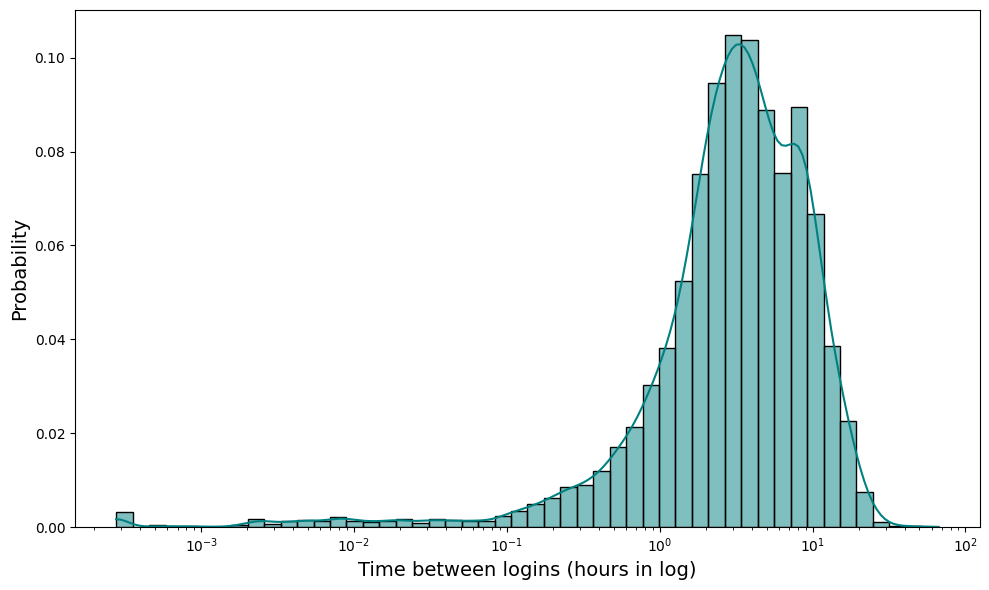

In [5]:
login['datetime'] = pd.to_timedelta(login['day'] - 1, unit='D') + pd.to_timedelta(login['time'])
login = login.sort_values(['user_id', 'datetime'])
login['delta_t'] = login.groupby('user_id')['datetime'].diff().dt.total_seconds() / 3600

deltas = login['delta_t'].dropna()
deltas = deltas[deltas > 0]

plt.figure(figsize=(10, 6))
sns.histplot(deltas, bins=50, kde=True, stat="probability", color='teal', log_scale=True)
plt.xlabel('Time between logins (hours in log)', fontsize=14)
plt.ylabel('Probability', fontsize=14)
plt.grid(False)
plt.tight_layout()
plt.show()

Media: 4.71 horas
Mediana: 3.37 horas
En días: 0.20 días (media) vs 0.14 días (mediana)


NameError: name 'cmap' is not defined

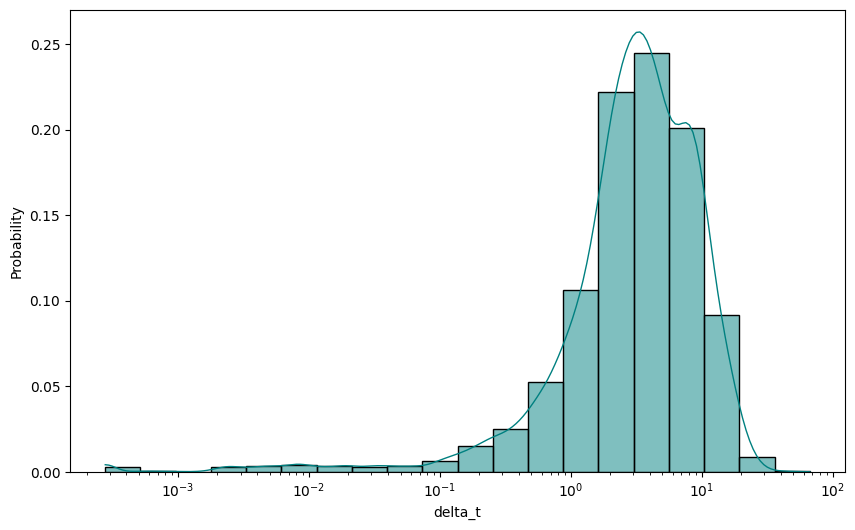

In [6]:
mean_delta = deltas.mean()
median_delta = deltas.median()

print(f"Media: {mean_delta:.2f} horas")
print(f"Mediana: {median_delta:.2f} horas")
print(f"En días: {mean_delta/24:.2f} días (media) vs {median_delta/24:.2f} días (mediana)")

plt.figure(figsize=(10, 6))

# Se usa el string 'color' con comillas para evitar el error de variable no definida
sns.histplot(
    deltas, 
    bins=20, 
    kde=True,  stat='probability',
    log_scale=True, 
    alpha=0.5, 
    color='#008080', line_kws={'color': 'black', 'linewidth': 1}
)

plt.axvline(mean_delta, color=cmap(5), linestyle='--', label=f'Mean: {mean_delta:.1f}h')
plt.axvline(median_delta, color='black', linestyle=':', label=f'Median: {median_delta:.1f}h')
plt.axvline(4.23, color=cmap(3), linestyle='-', label=f'Peak-to-peak mean distance: 4.36h')

plt.xlabel('Inter-event times (log hours)', fontsize=14)
plt.ylabel('Probability', fontsize=14)

# Configuración de los ticks hacia adentro
plt.tick_params(axis='both', direction='in', which='minor')
plt.tick_params(axis='both', direction='in', which='major', labelsize=12)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('figs/hours.png', bbox_inches='tight', dpi=300)
plt.show()

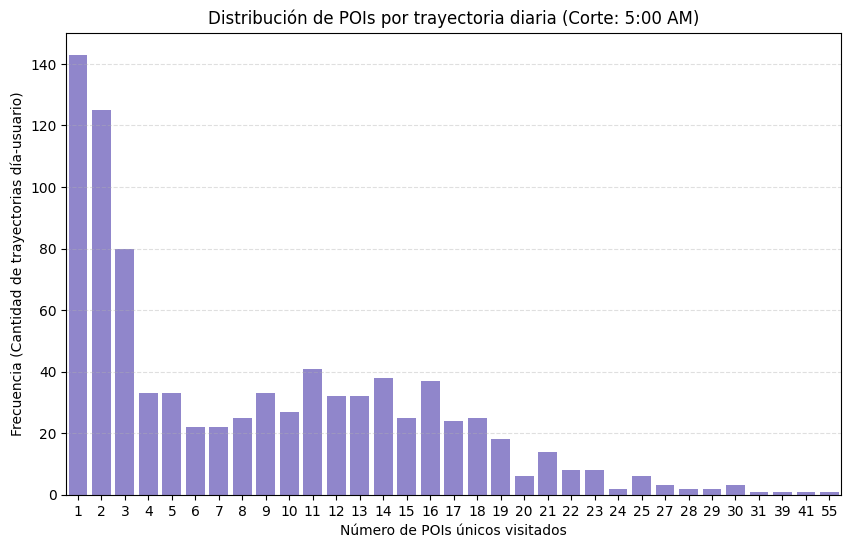

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cutoff = 5
checkins['time'] = pd.to_datetime(checkins['time'])
checkins['adj_time'] = checkins['time'] - pd.Timedelta(hours=cutoff)
checkins['adj_day'] = checkins['adj_time'].dt.date

res = checkins.groupby(['user_id', 'adj_day'])['POI_id'].nunique().reset_index(name='n_pois')

plt.figure(figsize=(10, 6))
sns.countplot(data=res, x='n_pois', color='slateblue', alpha=0.8)
plt.xlabel('Número de POIs únicos visitados')
plt.ylabel('Frecuencia (Cantidad de trayectorias día-usuario)')
plt.title(f'Distribución de POIs por trayectoria diaria (Corte: {cutoff}:00 AM)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [37]:
import pandas as pd

# 1. Calculamos de nuevo usando la columna del día lógico (4 AM)
# Asegúrate de haber ejecutado antes: 
# checkins['adj_day_4am'] = (checkins['time'] - pd.Timedelta(hours=4)).dt.date

res = checkins.groupby(['user_id', 'adj_day_4am'])['POI_id'].nunique().reset_index(name='n_pois')

# 2. Buscamos a los usuarios con alta actividad (más de 15 POIs únicos en ese día lógico)
umbral = 15
outliers = res[res['n_pois'] > umbral].sort_values(by='n_pois', ascending=False)

if not outliers.empty:
    # Cogemos el ejemplo más extremo para la auditoría
    top_user = outliers.iloc[0]['user_id']
    top_day_logico = outliers.iloc[0]['adj_day_4am']
    
    # 3. EXTRAER TRAYECTORIA REAL: Filtramos por el ADJ_DAY_4AM
    # Esto es vital para ver exactamente lo que el algoritmo de entropía "ve"
    audit = checkins[(checkins['user_id'] == top_user) & 
                     (checkins['adj_day_4am'] == top_day_logico)].sort_values(by='time')
    
    # Calculamos el tiempo entre check-ins consecutivos (en minutos)
    audit['time_diff'] = audit['time'].diff().dt.total_seconds() / 60
    
    # Calculamos cuántos son realmente únicos en esta sub-selección para verificar
    reales_unicos = audit['POI_id'].nunique()
    
    print(f"--- AUDITORÍA DE TRAYECTORIA LÓGICA (4:00 AM) ---")
    print(f"Usuario: {top_user}")
    print(f"Día Lógico (adj_day_4am): {top_day_logico}")
    print(f"POIs únicos detectados: {reales_unicos}")
    print(f"Total de check-ins en el día: {len(audit)}")
    print("-" * 50)
    
    # Mostramos los primeros 20 registros
    # Incluimos la hora original para que veas si hay registros de madrugada (00:00 - 04:00)
    print(audit[['time', 'POI_id', 'POI_category', 'time_diff']].head(20))
    
    if reales_unicos == outliers.iloc[0]['n_pois']:
        print(f"\n✅ VERIFICACIÓN CORRECTA: Los {reales_unicos} POIs coinciden con el conteo del reporte.")
    else:
        print(f"\n❌ ERROR DE CONTEO: Hay una discrepancia entre el reporte y la auditoría.")

else:
    print(f"No se encontraron usuarios con más de {umbral} POIs en un día lógico.")

--- AUDITORÍA DE TRAYECTORIA LÓGICA (4:00 AM) ---
Usuario: 99
Día Lógico (adj_day_4am): 2026-04-09
POIs únicos detectados: 55
Total de check-ins en el día: 87
--------------------------------------------------
                     time                POI_id  POI_category  time_diff
317   2026-04-09 06:51:56   6240187185276123346     Residence        NaN
2189  2026-04-09 07:00:06  10977201571865391224     Residence   8.166667
11388 2026-04-09 07:27:15   6240187185276123346     Residence  27.150000
17112 2026-04-09 07:34:02    990273439759100420     Residence   6.783333
3848  2026-04-09 07:35:03  11043157623396842992        School   1.016667
7534  2026-04-09 07:36:20   6240187185276123346     Residence   1.283333
9463  2026-04-09 07:57:20   6240187185276123346     Residence  21.000000
15430 2026-04-09 08:31:13   6240187185276123346     Residence  33.883333
5760  2026-04-09 08:31:16  16095099646781305779     Financial   0.050000
7659  2026-04-09 08:41:17   9163258265447847788      Cultura

In [26]:
res = checkins.groupby(['user_id', 'day'])['POI_id'].nunique().reset_index(name='n_pois')

# 2. Buscamos el valor máximo real en el dataframe de resultados
max_real = res['n_pois'].max()
print(f"El máximo real en el dataframe 'res' es: {max_real}")

# 3. Identificamos al usuario y el día del valor máximo
top_row = res[res['n_pois'] == max_real].iloc[0]
u_id = top_row['user_id']
u_day = top_row['day']

print(f"\n--- AUDITORÍA DEL MÁXIMO ---")
print(f"Usuario: {u_id} | Día: {u_day}")
print(f"Según 'res', este usuario visitó {max_real} POIs únicos ese día.")

# 4. Miramos sus datos crudos ese día para ver si hay algo raro
raw_data = checkins[(checkins['user_id'] == u_id) & (checkins['day'] == u_day)].sort_values(by='time')
print(f"\nPrimeros 10 check-ins de este usuario ese día:")
print(raw_data[['time', 'POI_id']].head(10))

# 5. Comprobación de seguridad: ¿Son realmente únicos?
unique_pois = raw_data['POI_id'].unique()
print(f"\nLista de POIs únicos contados: {len(unique_pois)}")

El máximo real en el dataframe 'res' es: 16

--- AUDITORÍA DEL MÁXIMO ---
Usuario: 99 | Día: 6
Según 'res', este usuario visitó 16 POIs únicos ese día.

Primeros 10 check-ins de este usuario ese día:
                     time                POI_id
9200  2026-03-23 00:16:59   6240187185276123346
9463  2026-03-23 07:57:20   6240187185276123346
9645  2026-03-23 09:17:32  14624418185447457320
9867  2026-03-23 10:47:41  11257892745349970971
9868  2026-03-23 10:47:49  15192729793732726753
9869  2026-03-23 10:47:56  11873406187507555652
9870  2026-03-23 10:48:05   6949076649787173565
9872  2026-03-23 10:48:14   7272720446072478133
9873  2026-03-23 10:48:21   6552456619915028642
10477 2026-03-23 17:24:34   8264171003901015939

Lista de POIs únicos contados: 16


5079
user_id
1      11
345    11
313    11
312    11
311    11
       ..
166     8
211     8
333     8
62      8
389     7
Name: count, Length: 467, dtype: int64
max: 11
min: 7


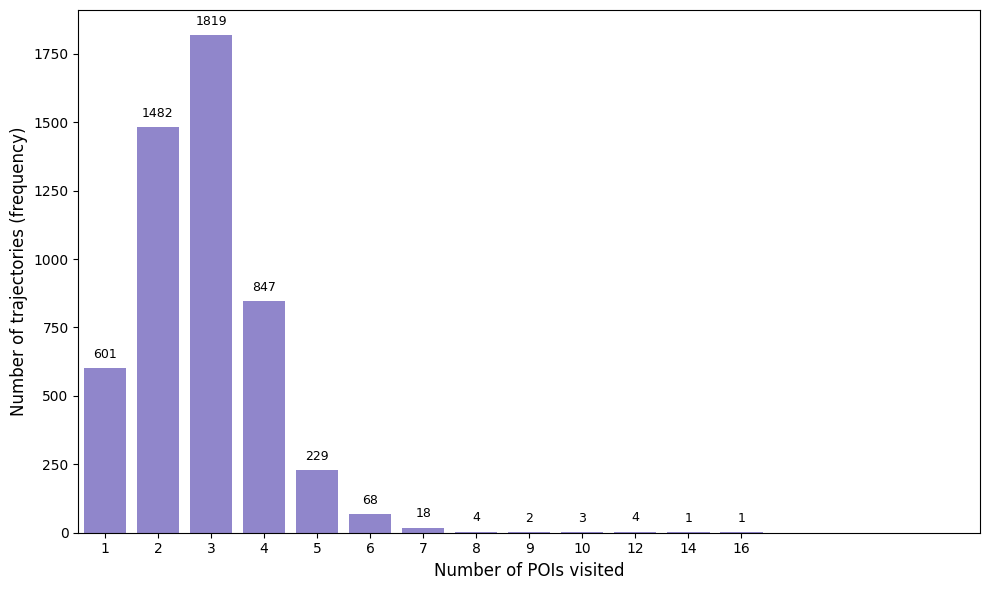

user_id    233.958063
day          5.964166
gender       0.633786
n_pois       2.805080
dtype: float64


In [9]:
plt.close('all')
res_final = checkins.groupby(['user_id', 'day', 'gender'])['POI_id'].nunique().reset_index(name='n_pois')
print(len(res_final))
traj_peruser = res_final['user_id'].value_counts()
print(traj_peruser)
print('max:', max(traj_peruser))
print('min:', min(traj_peruser))
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=res_final, x='n_pois', color='slateblue', alpha=0.8)
plt.xlim(-0.5, res_final['n_pois'].max() + 0.5)
plt.xlabel('Number of POIs visited', fontsize=12)
plt.ylabel('Number of trajectories (frequency)', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=9)
plt.grid(False)
plt.tight_layout()
plt.savefig('pois_total.png', bbox_inches='tight', dpi = 300)
plt.show()

print(res_final.mean())

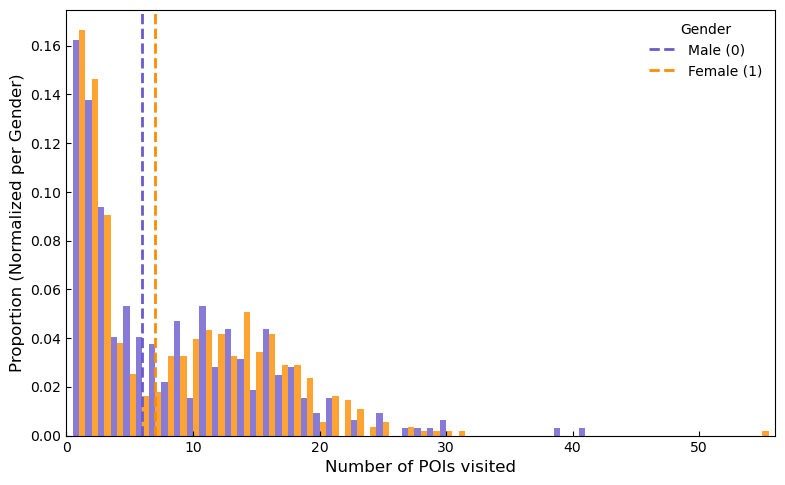

Estadísticas por Género:
        median       std
gender                  
0          6.0  7.191939
1          7.0  7.254227


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

checkins['time'] = pd.to_datetime(checkins['time'])
checkins['adj_day_4am'] = (checkins['time'] - pd.Timedelta(hours=4)).dt.date

res_final = checkins.groupby(['user_id', 'adj_day_4am', 'gender'])['POI_id'].nunique().reset_index(name='n_pois')
stats_gen = res_final.groupby('gender')['n_pois'].agg(['median', 'std'])

plt.figure(figsize=(8, 5))
palette_gender = {0: 'slateblue', 1: 'darkorange'}

# Usamos histplot para poder usar common_norm=False (normalización independiente por género)
ax = sns.histplot(
    data=res_final, 
    x='n_pois', 
    hue='gender', 
    palette=palette_gender, 
    alpha=0.8, 
    stat='proportion',
    common_norm=False, 
    multiple="dodge", 
    discrete=True, edgecolor=None
)

plt.xlabel('Number of POIs visited', fontsize=12)
plt.ylabel('Proportion (Normalized per Gender)', fontsize=12)

"""
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), textcoords='offset points', 
                    fontsize=8)
"""

# Líneas de media con el ajuste estético original
if 0 in stats_gen.index:
    plt.axvline(stats_gen.loc[0, 'median'], color='slateblue', linestyle='--', linewidth=2,
                label=f'Median Male: {stats_gen.loc[0, "median"]:.2f}')
if 1 in stats_gen.index:
    plt.axvline(stats_gen.loc[1, 'median'], color='darkorange', linestyle='--', linewidth=2,
                label=f'Median Female: {stats_gen.loc[1, "median"]:.2f}')

# Manejo de leyenda para mantener la estética original
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=['Male (0)', 'Female (1)'] + labels[2:], title='Gender', frameon=False)

# Configuración final de estilo
plt.grid(False)
plt.tight_layout()
plt.tick_params(axis='both', direction='in')
plt.xlim(0,56)
plt.savefig('distribucion_pois_genero_final.png', dpi=300)
plt.show()

print("Estadísticas por Género:")
print(stats_gen)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_rg_metrics(df_user):
    loc_counts = df_user.groupby(['latitude', 'longitude']).size().reset_index(name='n_i')
    if loc_counts.empty: return 0.0
    
    N = loc_counts['n_i'].sum()
    # Centro de masas
    r_cm_lat = (loc_counts['latitude'] * loc_counts['n_i']).sum() / N
    r_cm_lon = (loc_counts['longitude'] * loc_counts['n_i']).sum() / N
    
    # Conversión a km (Aproximación Haversine local)
    dx = (loc_counts['latitude'] - r_cm_lat) * 111
    dy = (loc_counts['longitude'] - r_cm_lon) * 111 * np.cos(np.radians(r_cm_lat))
    sq_dist = dx**2 + dy**2
    
    return np.sqrt((loc_counts['n_i'] * sq_dist).sum() / N)

# Calculamos Rg por usuario (o por usuario-día si prefieres cambiar el groupby)
results = checkins.groupby('user_id').apply(
    lambda d: pd.Series({
        'rg': calculate_rg_metrics(d), 
        'gender': d['gender'].iloc[0]
    })
).reset_index()

# Estadísticas para las líneas de media
stats_rg = results.groupby('gender')['rg'].agg(['mean', 'std'])

plt.figure(figsize=(10, 6))
# Usamos la misma paleta que en tu código anterior
palette_gender = {0: 'slateblue', 1: 'darkorange'}

# Graficamos KDE (Densidad)
sns.kdeplot(data=results, x='rg', hue='gender', palette=palette_gender, 
            fill=True, alpha=0.4, linewidth=2, common_norm=False)

# Líneas de media con la misma estética de los POIs
if 0 in stats_rg.index:
    plt.axvline(stats_rg.loc[0, 'mean'], color='slateblue', linestyle='--', linewidth=2,
                label=f'Mean Male: {stats_rg.loc[0, "mean"]:.2f} km')
if 1 in stats_rg.index:
    plt.axvline(stats_rg.loc[1, 'mean'], color='darkorange', linestyle='--', linewidth=2,
                label=f'Mean Female: {stats_rg.loc[1, "mean"]:.2f} km')

# Configuración de ejes y estilo (idéntico a tu primer código)
plt.xlabel('Radius of Gyration ($R_g$) [km]', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Límite en X basado en el percentil 99 para evitar que outliers aplasten la gráfica
x_limit = results['rg'].quantile(0.99)
plt.xlim(0, x_limit)

# Leyenda consistente
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(frameon=False, fontsize=10)

plt.tick_params(axis='both', direction='in')
plt.grid(False)
plt.tight_layout()
plt.savefig('rg_genero_consistente.png', dpi=300)
plt.show()

print("Estadísticas de Rg por Género:")
print(stats_rg)

In [35]:
import pandas as pd
import numpy as np

# 1. Aseguramos que el tiempo sea datetime
checkins['time'] = pd.to_datetime(checkins['time'])

# 2. LOGICA DE MADRUGADA:
# Restamos 4 horas. Así, lo que pasó el día 10 a las 03:00 AM, 
# al restarle 4 horas, pasa a ser día 9 a las 23:00 PM.
checkins['adj_time'] = checkins['time'] - pd.Timedelta(hours=4)
checkins['adj_day'] = checkins['adj_time'].dt.date

# 3. AGRUPACIÓN SIN FILTROS:
# Agrupamos por usuario y por el nuevo día ajustado.
# Esto incluirá trayectorias de 1 solo check-in, de 2, y de 50. No discrimina.
res_final = checkins.groupby(['user_id', 'adj_day'])['POI_id'].nunique().reset_index(name='n_pois')

# 4. CÁLCULO DE PARÁMETROS:
# Usamos la Mediana para l_star porque es más estable, 
# pero puedes usar la media si prefieres.
l_star_global = res_final['n_pois'].median()
deviation_global = res_final['n_pois'].std()

# --- VERIFICACIÓN DE SEGURIDAD ---
print(f"Registros originales en checkins: {len(checkins)}")
# La suma de check-ins en las trayectorias debería ser igual a los originales 
# si hiciéramos un count(), pero aquí contamos sitios únicos (nunique).
print(f"Total de trayectorias generadas (incluyendo de 1 POI): {len(res_final)}")
print(f"Media resultante: {res_final['n_pois'].mean():.2f}")
print(f"Mediana resultante (l_star): {l_star_global:.2f}")
print(f"Desviación estándar (sigma): {deviation_global:.2f}")

Registros originales en checkins: 20397
Total de trayectorias generadas (incluyendo de 1 POI): 873
Media resultante: 8.42
Mediana resultante (l_star): 7.00
Desviación estándar (sigma): 7.23


In [23]:
# 1. Generar un archivo CSV (más ligero y compatible)
res_final.to_csv('reporte_trayectorias_pois.csv', index=False)

# 2. Generar un archivo Excel (necesitas tener instalada la librería openpyxl)
# !pip install openpyxl
res_final.to_excel('reporte_trayectorias_pois.xlsx', index=False)

# 3. Mostrar las primeras filas en consola para verificar
print("Vista previa del reporte:")
print(res_final.head(10))

Vista previa del reporte:
   user_id adj_day_4am  n_pois
0        1  2026-04-08       1
1        1  2026-04-09      16
2        2  2026-04-08       2
3        2  2026-04-09       8
4        3  2026-04-08       2
5        3  2026-04-09       7
6        4  2026-04-08       3
7        4  2026-04-09      13
8        5  2026-04-08       1
9        5  2026-04-09      12


Total usuarios únicos: 467
Promedio de días activos por usuario: 1.87 días
Máximo de días que un usuario estuvo activo: 2
Mínimo de días que un usuario estuvo activo: 1


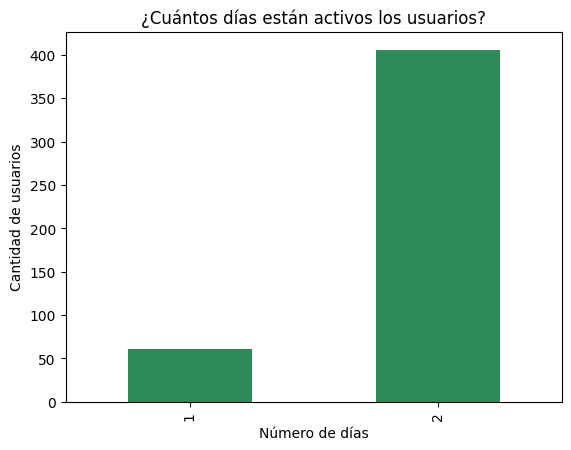

In [13]:
dias_por_usuario = res_final.groupby('user_id').size()
print(f"Total usuarios únicos: {len(dias_por_usuario)}")
print(f"Promedio de días activos por usuario: {dias_por_usuario.mean():.2f} días")
print(f"Máximo de días que un usuario estuvo activo: {dias_por_usuario.max()}")
print(f"Mínimo de días que un usuario estuvo activo: {dias_por_usuario.min()}")
import matplotlib.pyplot as plt
dias_por_usuario.value_counts().sort_index().plot(kind='bar', color='seagreen')
plt.title('¿Cuántos días están activos los usuarios?')
plt.xlabel('Número de días')
plt.ylabel('Cantidad de usuarios')
plt.show()

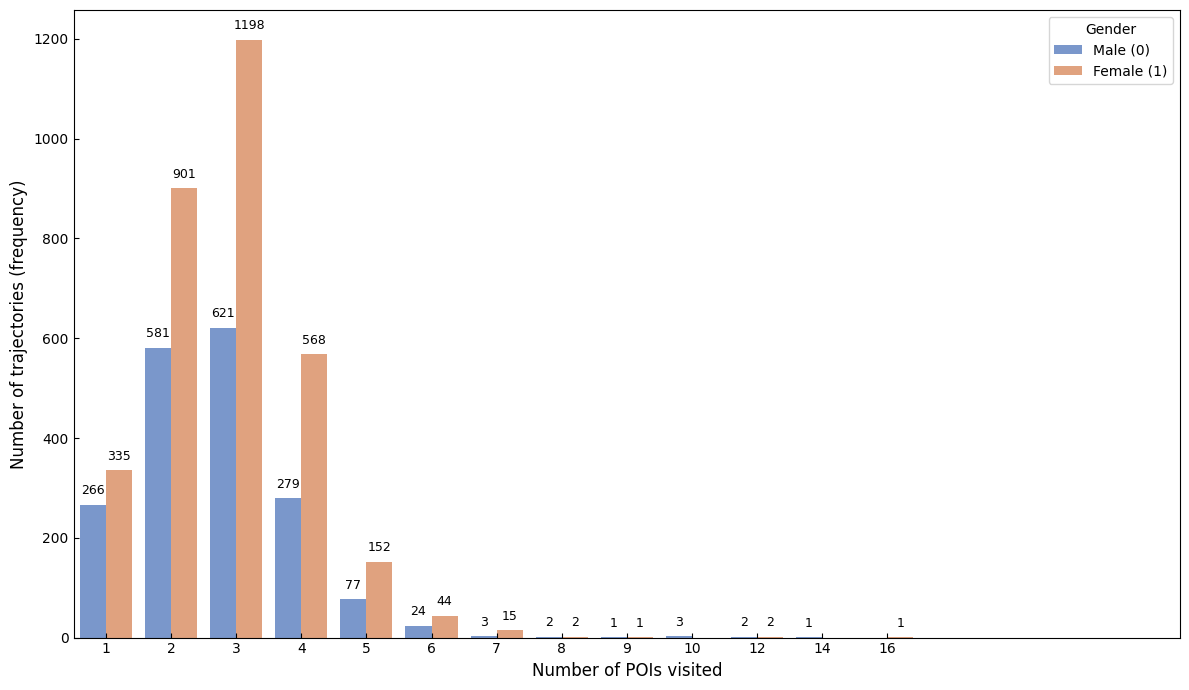

L_star para hombres: 3.0
L_star para mujeres: 3.0
3.0
dev para hombres: 1.240559508377815
dev para mujeres: 1.1698864637351016
1.1980873676115353


In [86]:
plt.figure(figsize=(12, 7))
ax = sns.countplot(data=res_final, x='n_pois', hue='gender', palette='muted', alpha=0.8)
plt.xlim(-0.5, res_final['n_pois'].max() + 0.5)
plt.xlabel('Number of POIs visited', fontsize=12)
plt.ylabel('Number of trajectories (frequency)', fontsize=12)
plt.legend(title='Gender', labels=['Male (0)', 'Female (1)'])

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points', 
                    fontsize=9)

plt.grid(False)
plt.tick_params(axis='both', direction='in')
plt.tight_layout()
plt.show()

l_star_gender = res_final.groupby('gender')['n_pois'].median()

print(f"L_star para hombres: {l_star_gender[0]}")
print(f"L_star para mujeres: {l_star_gender[1]}")

l_star_global = res_final['n_pois'].median()
print(l_star_global)

dev_gender = res_final.groupby('gender')['n_pois'].std()
print(f"dev para hombres: {dev_gender[0]}")
print(f"dev para mujeres: {dev_gender[1]}")
deviation = res_final['n_pois'].std()
print(deviation)

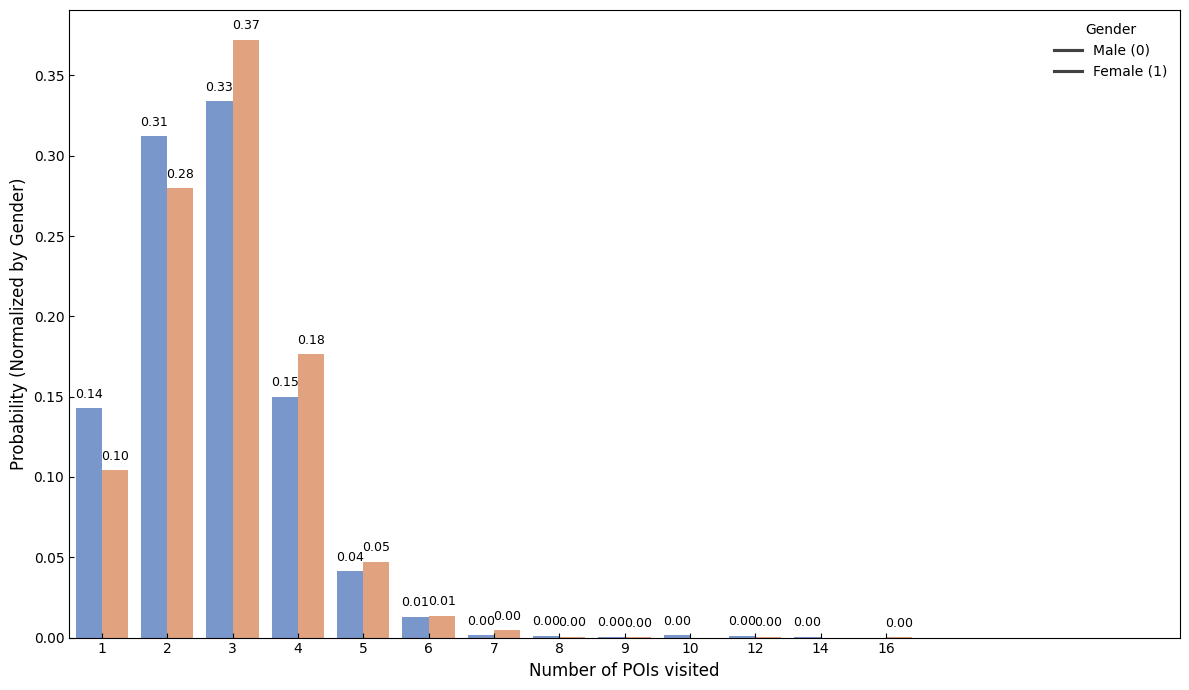

In [75]:
table_norm = res_final.groupby('gender')['n_pois'].value_counts(normalize=True).reset_index(name='probability')
def format_label(val):
    if val == 0: return "0"
    if val >= 0.01: return f"{val:.2f}"
    # Si es menor a 0.01, busca el primer decimal significativo
    import math
    precision = abs(int(math.floor(math.log10(abs(val)))))
    return f"{val:.{precision}f}"
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=table_norm, x='n_pois', y='probability', hue='gender', palette='muted', alpha=0.8)
plt.xlim(-0.5, res_final['n_pois'].max() + 0.5)
plt.xlabel('Number of POIs visited', fontsize=12)
plt.ylabel('Probability (Normalized by Gender)', fontsize=12)
plt.legend(title='Gender', labels=['Male (0)', 'Female (1)'], frameon = False)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        label = format_label(height)
        ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=9)
plt.grid(False)
plt.tick_params(axis='both', direction='in')
plt.tight_layout()
plt.savefig('figs/poisprob.png', bbox_inches='tight', dpi = 300)
plt.show()

In [18]:
table = traj_peruser.value_counts().sort_index().reset_index(name='Users')
table.columns = ['Nº of trajectories', 'Users']
total_usuarios = table['Users'].sum()
table['% of Users'] = (table['Users'] / total_usuarios * 100).round(2)
print(table.to_string(index=False))

 Nº of trajectories  Users  % of Users
                  7      1        0.21
                  8      7        1.50
                  9      6        1.28
                 10     21        4.50
                 11    432       92.51


C:\Users\34633\AppData\Local\Temp\ipykernel_31188\4151454970.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = checkins.groupby('user_id').apply(lambda d: pd.Series({'rg': calculate_rg_metrics(d), 'gender': d['gender'].iloc[0]}))


Radio de Giro (Rg) medio por género:
gender
0.0    86.990826
1.0    55.698243
Name: rg, dtype: float64

Resumen detallado:
             mean         std  count
gender                              
0.0     86.990826  415.729739    172
1.0     55.698243  420.698488    295


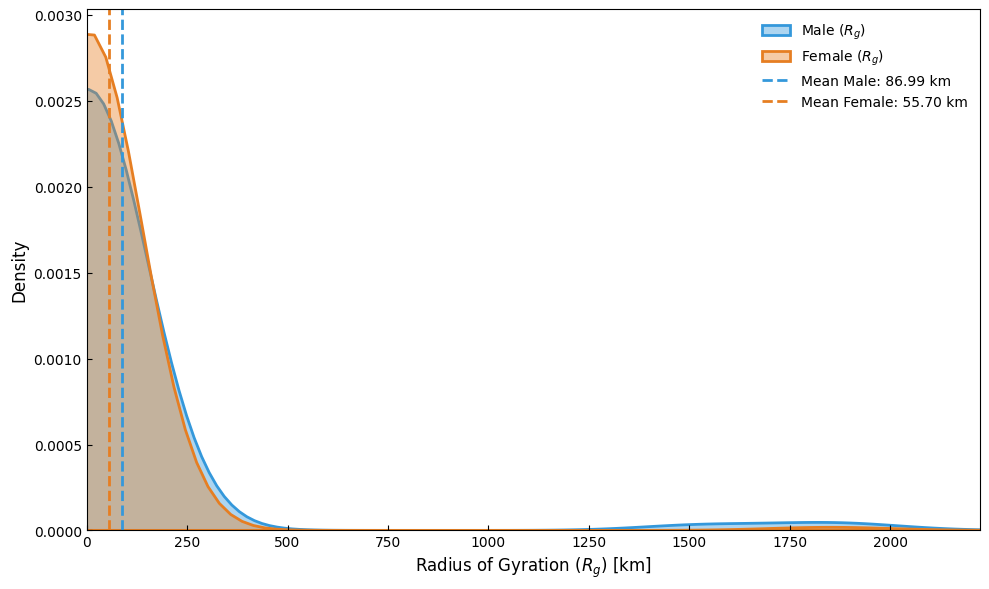

In [73]:
def calculate_rg_metrics(df_user, k_value=2):
    loc_counts = df_user.groupby(['latitude', 'longitude']).size().reset_index(name='n_i')
    loc_counts = loc_counts.sort_values(by='n_i', ascending=False).reset_index(drop=True)
    def get_rg(df_subset):
        if df_subset.empty: return 0.0
        N = df_subset['n_i'].sum()
        r_cm_lat = (df_subset['latitude'] * df_subset['n_i']).sum() / N
        r_cm_lon = (df_subset['longitude'] * df_subset['n_i']).sum() / N
        dx = (df_subset['latitude'] - r_cm_lat) * 111
        dy = (df_subset['longitude'] - r_cm_lon) * 111 * np.cos(np.radians(r_cm_lat))
        sq_dist = dx**2 + dy**2
        return np.sqrt((df_subset['n_i'] * sq_dist).sum() / N)
    return get_rg(loc_counts)
    
results = checkins.groupby('user_id').apply(lambda d: pd.Series({'rg': calculate_rg_metrics(d), 'gender': d['gender'].iloc[0]}))
rg_table = results.reset_index()
medias_genero = rg_table.groupby('gender')['rg'].mean()
print("Radio de Giro (Rg) medio por género:")
print(medias_genero)
print("\nResumen detallado:")
print(rg_table.groupby('gender')['rg'].agg(['mean', 'std', 'count']))


male_rg = rg_table[rg_table['gender'] == 0]['rg'].dropna()
female_rg = rg_table[rg_table['gender'] == 1]['rg'].dropna()
mean_male = male_rg.mean()
mean_female = female_rg.mean()

plt.figure(figsize=(10, 6))
colors = ['#3498db', '#e67e22'] 
sns.kdeplot(male_rg, fill=True, color=colors[0], label='Male ($R_g$)', alpha=0.4, linewidth=2)
sns.kdeplot(female_rg, fill=True, color=colors[1], label='Female ($R_g$)', alpha=0.4, linewidth=2)
plt.axvline(mean_male, color=colors[0], linestyle='--', linewidth=2, label=f'Mean Male: {mean_male:.2f} km')
plt.axvline(mean_female, color=colors[1], linestyle='--', linewidth=2, label=f'Mean Female: {mean_female:.2f} km')
plt.xlabel('Radius of Gyration ($R_g$) [km]', fontsize=12)
plt.ylabel('Density', fontsize=12)
x_limit = rg_table['rg'].quantile(0.99)
plt.xlim(0, x_limit)
plt.legend(frameon=False, fontsize=10)
plt.tick_params(axis='both', direction='in', labelsize=10)
plt.grid(False)
plt.tight_layout()
plt.savefig('rg.png', bbox_inches='tight', dpi = 300)
plt.show()

C:\Users\34633\AppData\Local\Temp\ipykernel_27968\2702953577.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = checkins.groupby('user_id').apply(


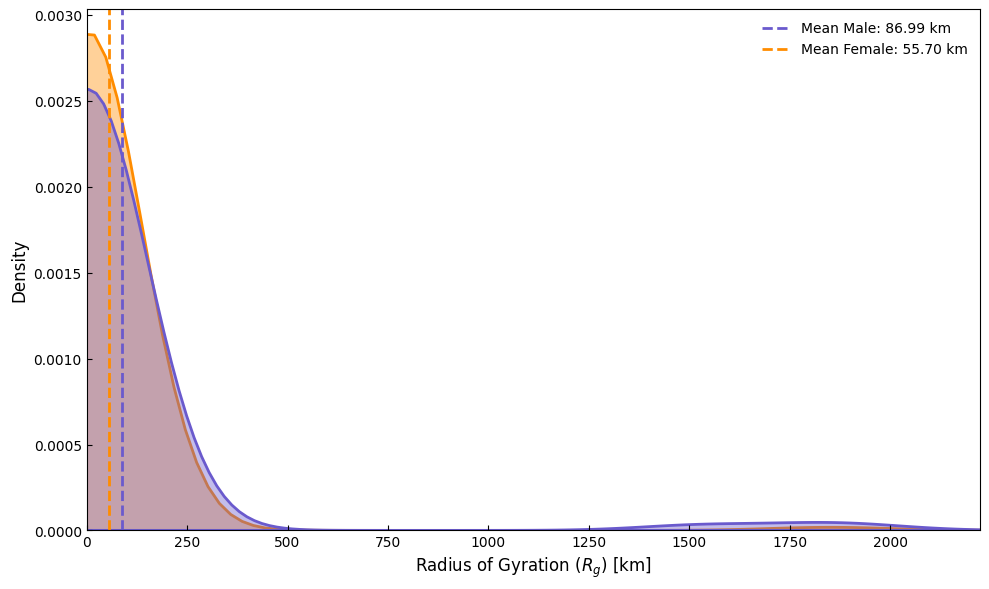

Estadísticas de Rg por Género:
             mean         std
gender                       
0.0     86.990826  415.729739
1.0     55.698243  420.698488


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_rg_metrics(df_user):
    loc_counts = df_user.groupby(['latitude', 'longitude']).size().reset_index(name='n_i')
    if loc_counts.empty: return 0.0
    
    N = loc_counts['n_i'].sum()
    # Centro de masas
    r_cm_lat = (loc_counts['latitude'] * loc_counts['n_i']).sum() / N
    r_cm_lon = (loc_counts['longitude'] * loc_counts['n_i']).sum() / N
    
    # Conversión a km (Aproximación Haversine local)
    dx = (loc_counts['latitude'] - r_cm_lat) * 111
    dy = (loc_counts['longitude'] - r_cm_lon) * 111 * np.cos(np.radians(r_cm_lat))
    sq_dist = dx**2 + dy**2
    
    return np.sqrt((loc_counts['n_i'] * sq_dist).sum() / N)

# Calculamos Rg por usuario (o por usuario-día si prefieres cambiar el groupby)
results = checkins.groupby('user_id').apply(
    lambda d: pd.Series({
        'rg': calculate_rg_metrics(d), 
        'gender': d['gender'].iloc[0]
    })
).reset_index()

# Estadísticas para las líneas de media
stats_rg = results.groupby('gender')['rg'].agg(['mean', 'std'])

plt.figure(figsize=(10, 6))
# Usamos la misma paleta que en tu código anterior
palette_gender = {0: 'slateblue', 1: 'darkorange'}

# Graficamos KDE (Densidad)
sns.kdeplot(data=results, x='rg', hue='gender', palette=palette_gender, 
            fill=True, alpha=0.4, linewidth=2, common_norm=False)

# Líneas de media con la misma estética de los POIs
if 0 in stats_rg.index:
    plt.axvline(stats_rg.loc[0, 'mean'], color='slateblue', linestyle='--', linewidth=2,
                label=f'Mean Male: {stats_rg.loc[0, "mean"]:.2f} km')
if 1 in stats_rg.index:
    plt.axvline(stats_rg.loc[1, 'mean'], color='darkorange', linestyle='--', linewidth=2,
                label=f'Mean Female: {stats_rg.loc[1, "mean"]:.2f} km')

# Configuración de ejes y estilo (idéntico a tu primer código)
plt.xlabel('Radius of Gyration ($R_g$) [km]', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Límite en X basado en el percentil 99 para evitar que outliers aplasten la gráfica
x_limit = results['rg'].quantile(0.99)
plt.xlim(0, x_limit)

# Leyenda consistente
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(frameon=False, fontsize=10)

plt.tick_params(axis='both', direction='in')
plt.grid(False)
plt.tight_layout()
plt.savefig('rg_genero_consistente.png', dpi=300)
plt.show()

print("Estadísticas de Rg por Género:")
print(stats_rg)

In [82]:
checkins['hour_val'] = pd.to_datetime(checkins['time']).dt.hour
checkins['logical_day'] = checkins.apply(lambda x: x['day'] if x['hour_val'] >= 4 else x['day'] - 1, axis=1)

filtro = (checkins['user_id'] == 8) & (checkins['logical_day'] == 5)
resultado = checkins.loc[filtro]

resultado_final = resultado.sort_values(by=['day', 'time'])[['day', 'time', 'POI_id', 'POI_category']]
print(resultado_final)

C:\Users\34633\AppData\Local\Temp\ipykernel_31188\3214118492.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  checkins['hour_val'] = pd.to_datetime(checkins['time']).dt.hour


      day      time                POI_id POI_category
7511    5  07:25:12   2187661556938708261     Cultural
7883    5  09:57:39   7851260396140490874       School
8201    5  12:15:54  14259473054975606407    Residence
8697    5  16:34:08   7851260396140490874       School
9097    6  00:03:31  14259473054975606407    Residence


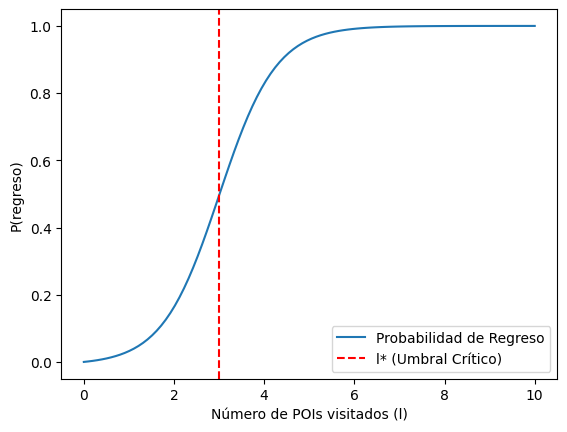

In [97]:
import numpy as np
import matplotlib.pyplot as plt

def p_regreso_inferida(A, l, l_star, sigma):
    kbt_a = A * (sigma * np.sqrt(3)) / np.pi
    exponent = -(l - l_star) / kbt_a
    
    p = 1 / (1 + np.exp(exponent))

    p_0 = 1 / (1 + np.exp(l_star / kbt_a))
    return (p - p_0) / (1 - p_0)

l_range = np.linspace(0, 10, 100)
probabilidades = p_regreso_inferida(0.9562946009839345, l_range, 3, 1.198)

plt.plot(l_range, probabilidades, label='Probabilidad de Regreso')
plt.axvline(x=3, color='r', linestyle='--', label='l* (Umbral Crítico)')
plt.xlabel('Número de POIs visitados (l)')
plt.ylabel('P(regreso)')
plt.legend()
plt.show()

In [93]:
checkins['hour_val'] = pd.to_datetime(checkins['time']).dt.hour
checkins['logical_day'] = checkins.apply(lambda x: x['day'] if x['hour_val'] >= 4 else x['day'] - 1, axis=1)
l_star = 3
sigma = 1.198
P_target = 0.95 
resultados = []

for (uid, l_day), group in checkins.groupby(['user_id', 'logical_day']):
    group = group.sort_values(by=['day', 'time'])
    l_final = len(group)
    if l_final > l_star:
        term_log = -np.log((1 / P_target) - 1)
        kbt_a_needed = (l_final - l_star) / term_log
        A_calculada = kbt_a_needed * np.pi / (sigma * np.sqrt(3))
    else:
        A_calculada = np.nan
    resultados.append({'user_id': uid,'logical_day': l_day,'n_pois': l_final,'A_inferida': A_calculada})
df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv('resultados_A_por_usuario_dia.csv', index=False)
print("Archivo 'resultados_A_por_usuario_dia.csv' generado con éxito.")

C:\Users\34633\AppData\Local\Temp\ipykernel_31188\1117977916.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  checkins['hour_val'] = pd.to_datetime(checkins['time']).dt.hour


Archivo 'resultados_A_por_usuario_dia.csv' generado con éxito.


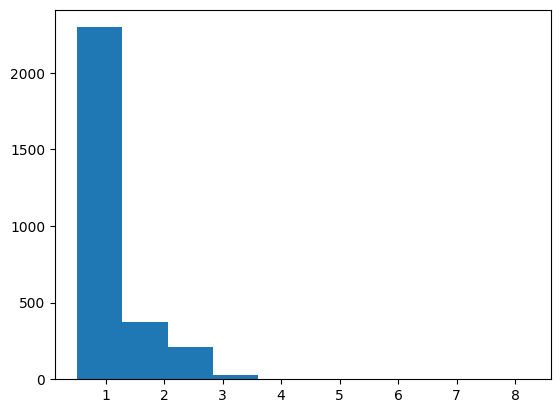

0.9562946009839345


In [96]:
plt.hist(Aresults, bins=10)
plt.show()

Aresults = df_resultados['A_inferida']
A = Aresults.mean()
print(A)

C:\Users\34633\AppData\Local\Temp\ipykernel_31188\633819219.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  checkins['hour_val'] = pd.to_datetime(checkins['time']).dt.hour


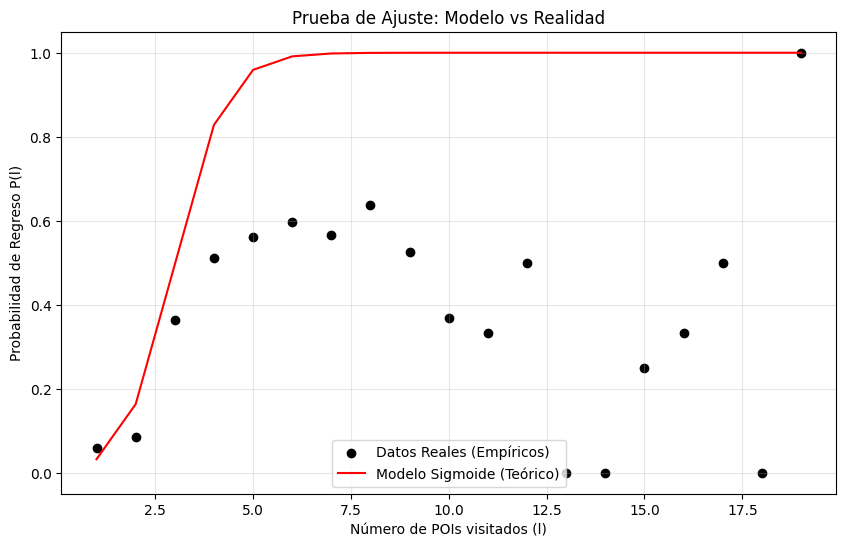

Error cuadrático medio: 0.5774


In [100]:
checkins['hour_val'] = pd.to_datetime(checkins['time']).dt.hour
checkins['logical_day'] = checkins.apply(lambda x: x['day'] if x['hour_val'] >= 4 else x['day'] - 1, axis=1)

trayectorias = []
for (uid, l_day), group in checkins.groupby(['user_id', 'logical_day']):
    group = group.sort_values(by=['day', 'time'])
    n_total = len(group)
    for i in range(n_total):
        es_ultimo = 1 if i == (n_total - 1) else 0
        trayectorias.append({'l': i + 1, 'regreso_real': es_ultimo})

df_prueba = pd.DataFrame(trayectorias)
prob_empirica = df_prueba.groupby('l')['regreso_real'].mean().reset_index()

def p_teorica(l, A, l_star, sigma):
    kbt_a = A * (sigma * np.sqrt(3)) / np.pi
    exponent = -(l - l_star) / kbt_a
    p = 1 / (1 + np.exp(exponent))
    p_0 = 1 / (1 + np.exp(l_star / kbt_a))
    return (p - p_0) / (1 - p_0)

A_media = A
l_vals = prob_empirica['l'].values
y_teorico = p_teorica(l_vals, A_media, 3, 1.198)

plt.figure(figsize=(10, 6))
plt.scatter(prob_empirica['l'], prob_empirica['regreso_real'], color='black', label='Datos Reales (Empíricos)')
plt.plot(l_vals, y_teorico, color='red', label='Modelo Sigmoide (Teórico)')
plt.xlabel('Número de POIs visitados (l)')
plt.ylabel('Probabilidad de Regreso P(l)')
plt.title('Prueba de Ajuste: Modelo vs Realidad')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

rmse = np.sqrt(np.mean((prob_empirica['regreso_real'] - y_teorico)**2))
print(f"Error cuadrático medio: {rmse:.4f}")

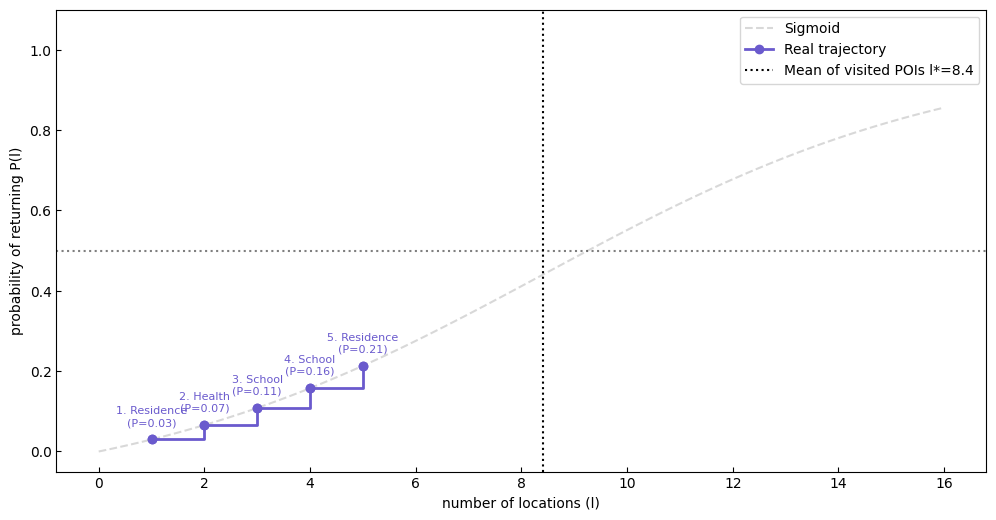

In [30]:
def p_teorica(l, A, l_star, sigma):
    kbt_a = A * (sigma * np.sqrt(3)) / np.pi
    exponent = -(l - l_star) / kbt_a
    p = 1 / (1 + np.exp(exponent))
    p_0 = 1 / (1 + np.exp(l_star / kbt_a))
    return (p - p_0) / (1 - p_0)

user_id = 1
dia_logico = 5
#l_star = 3
l_star = 8.4
sigma = 7.2
#sigma = 1.198
A_valor = 1.0 

checkins['hour_val'] = pd.to_datetime(checkins['time']).dt.hour
checkins['logical_day'] = checkins.apply(lambda x: x['day'] if x['hour_val'] >= 4 else x['day'] - 1, axis=1)

trayectoria = checkins[(checkins['user_id'] == user_id) & (checkins['logical_day'] == dia_logico)].sort_values(by=['day', 'time'])
n_steps = len(trayectoria)
steps_reales = np.arange(1, n_steps + 1)
probs_reales = [p_teorica(l, A_valor, l_star, sigma) for l in steps_reales]

l_continuo = np.linspace(0, 16, 100)
p_continua = p_teorica(l_continuo, A_valor, l_star, sigma)

plt.figure(figsize=(12, 6))

plt.plot(l_continuo, p_continua, color='gray', alpha=0.3, label='Sigmoid', linestyle='--')
plt.step(steps_reales, probs_reales, where='post', color='slateblue', linewidth=2, label='Real trajectory', marker='o')
plt.scatter(steps_reales, probs_reales, marker='o', color='slateblue')

for i, (poi, p) in enumerate(zip(trayectoria['POI_category'], probs_reales)):
    plt.annotate(f"{i+1}. {poi}\n(P={p:.2f})", (steps_reales[i], p), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='slateblue')

plt.axvline(x=l_star, color='black', linestyle=':', label='Mean of visited POIs l*=8.4')
plt.axhline(y=0.5, color='black', linestyle=':', alpha=0.5)

plt.ylim(-0.05, 1.1)
#plt.xlim(0, max(n_steps + 1, 6))
plt.xlabel('number of locations (l)')
plt.ylabel('probability of returning P(l)')
plt.legend()
plt.grid(False)
plt.tick_params(axis='both', direction='in')
plt.show()

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filtro por fecha exacta (evita errores de índices de día)
user_id = 1
fecha_objetivo = '2026-04-09' 

# Aplicamos la misma lógica de 4 AM para filtrar la trayectoria
checkins['time'] = pd.to_datetime(checkins['time'])
checkins['adj_time'] = checkins['time'] - pd.Timedelta(hours=4)
checkins['adj_day'] = checkins['adj_time'].dt.date

# Obtenemos la trayectoria real de ese usuario ese día
# Convertimos fecha_objetivo a date para comparar
trayectoria = checkins[(checkins['user_id'] == user_id) & 
                        (checkins['adj_day'] == pd.to_datetime(fecha_objetivo).date())].sort_values(by='time')

# 2. Calcular l (lugares únicos visitados HASTA cada paso)
# Esto es vital: l solo aumenta cuando el POI es nuevo
l_evolucion = []
sitios_vistos = set()
for poi in trayectoria['POI_id']:
    sitios_vistos.add(poi)
    l_evolucion.append(len(sitios_vistos))

n_total_steps = len(trayectoria)
l_final = l_evolucion[-1] # Esto debería ser 16 según tu reporte

# 3. Probabilidades teóricas para esos valores de l
probs_reales = [p_teorica(l, A_valor, l_star, sigma) for l in l_evolucion]

# 4. Configuración del gráfico
l_max_grafico = max(l_final + 2, 20) 
l_continuo = np.linspace(0, l_max_grafico, 100)
p_continua = p_teorica(l_continuo, A_valor, l_star, sigma)

plt.figure(figsize=(12, 6))

# Curva teórica
plt.plot(l_continuo, p_continua, color='gray', alpha=0.3, label='Sigmoid', linestyle='--')

# Trayectoria Real: Usamos l_evolucion en el eje X
# Usamos 'drawstyle' para ver cómo sube la probabilidad al descubrir sitios
plt.step(l_evolucion, probs_reales, where='post', color='slateblue', linewidth=2, label=f'User {user_id} ({fecha_objetivo})', marker='o')

# Anotaciones (solo cuando l aumenta para no amontonar texto)
last_l = -1
for i, (poi_cat, l_act, p_act) in enumerate(zip(trayectoria['POI_category'], l_evolucion, probs_reales)):
    if l_act > last_l: # Solo anotamos si es un lugar nuevo
        plt.annotate(f"{l_act}. {poi_cat}", (l_act, p_act), 
                     textcoords="offset points", xytext=(0,10), 
                     ha='center', fontsize=7, color='slateblue', rotation=45)
        last_l = l_act

plt.axvline(x=l_star, color='black', linestyle=':', label=f'l* = {l_star}')
plt.axhline(y=0.5, color='black', linestyle=':', alpha=0.5)

plt.xlim(0, l_max_grafico)
plt.ylim(-0.05, 1.1)
plt.xlabel('Number of distinct locations visited (l)')
plt.ylabel('Probability of returning $P(l)$')
plt.legend(frameon=False)
plt.grid(False)
plt.tick_params(axis='both', direction='in')
plt.savefig('figs/return.png', dpi = 300)
plt.show()

IndexError: list index out of range

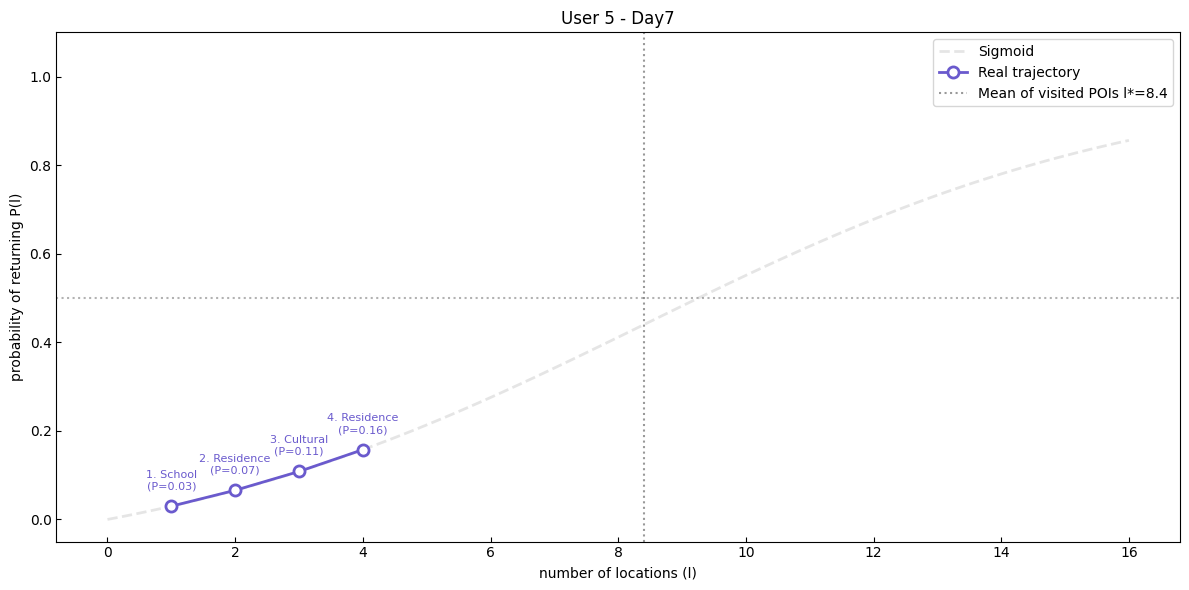

In [20]:
user_id = 5
dia_logico = 7
l_star = 8.4
#sigma = 1.198
sigma = 7.2
A_valor = 1.0 

checkins['hour_val'] = pd.to_datetime(checkins['time']).dt.hour
checkins['logical_day'] = checkins.apply(lambda x: x['day'] if x['hour_val'] >= 4 else x['day'] - 1, axis=1)
trayectoria = checkins[(checkins['user_id'] == user_id) & (checkins['logical_day'] == dia_logico)].sort_values(by=['day', 'time'])
n_steps = len(trayectoria)
steps_reales = np.arange(1, n_steps + 1)
probs_reales = [p_teorica(l, A_valor, l_star, sigma) for l in steps_reales]

l_continuo = np.linspace(0, 16, 100)
p_continua = p_teorica(l_continuo, A_valor, l_star, sigma)

plt.figure(figsize=(12, 6))
plt.plot(l_continuo, p_continua, color='gray', alpha=0.2, label='Sigmoid', linestyle='--', linewidth=2)
plt.plot(steps_reales, probs_reales, color='slateblue', marker='o', markersize=8, linewidth=2, label='Real trajectory', markerfacecolor='white', markeredgewidth=2)
for i, (poi, p) in enumerate(zip(trayectoria['POI_category'], probs_reales)):
    plt.annotate(f"{i+1}. {poi}\n(P={p:.2f})", (steps_reales[i], p), textcoords="offset points", xytext=(0,12), ha='center', fontsize=8, color='slateblue')

plt.axvline(x=l_star, color='black', linestyle=':', alpha=0.4, label=f'Mean of visited POIs l*={l_star}')
plt.axhline(y=0.5, color='black', linestyle=':', alpha=0.3)
plt.ylim(-0.05, 1.1)
#plt.xlim(0, max(n_steps + 1, 6))
plt.xlabel('number of locations (l)')
plt.ylabel('probability of returning P(l)')
plt.title(f'User {user_id} - Day{dia_logico}')
plt.legend()
plt.grid(False)
plt.tick_params(direction='in', axis='both')
plt.tight_layout()
plt.savefig('figs/sigmoid.png', bbox_inches='tight', dpi = 300)
plt.show()

In [37]:
print(checkins.isna().sum())

user_id         0
day             0
day_of_week     0
time            0
latitude        0
longitude       0
POI_id          0
POI_category    0
mood            0
gender          0
mov_day         0
coords          0
dtype: int64
